<a href="https://colab.research.google.com/github/PPraveen2230/Atees-Airbnb-Dataset-Machine-learning-/blob/main/Pipeline2_i_Withdopant_composition_experimental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

======================================================================================

 BCZT d33 ML PROJECT — PIPELINE 2-i: Composition+Dopants, Experimental

=======================================================================================

This notebook is part of a machine learning study predicting the piezoelectric coefficient d33 of BCZT (Barium Calcium Zirconate Titanate) ceramics, a lead-free piezoelectric material, using a dataset compiled from over 123 published journal articles. This particular notebook covers Pipeline 2-i, which incorporates dopant-site composition alongside the host BCZT composition, using only experimental descriptors — sintering and calcination temperature, grain size, Curie temperature, dopant identity/concentration, and synthesis method — drawn directly from the literature.

This pipeline tests whether adding dopant information — widely reported in the BCZT literature as the dominant lever for piezoelectric response — substantially improves predictive performance for d33.

In [1]:
# ============================================================
# Chunk 1: Step 1 — Import libraries + load dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Dataset already uploaded to Colab session storage
DATA_PATH = '/content/Master_Dataset.xlsx'  # adjust filename if it differs
df_raw = pd.read_excel(DATA_PATH, sheet_name='Master_Dataset')

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Loaded: /content/Master_Dataset.xlsx
Shape: (1175, 86)


,No,Compositions,Ba,Ca,Zr,Ti,O,d33,d33_unit,d33_measured_temperature,Calcination_Temp_C,Sintering_Temp_C,Grain_size,Tc,Synthesis_method,Journal_number,dopant1,dopant2,Percentage_of_dopant1,Percentage_of_dopant2,ANA,ANB,A-O(Å),ARA(pm),ARB(pm),B-O(Å),CA-a(Å),CA-b(Å),CA-c(Å),CB-a(Å),CB-b(Å),CB-c(Å),CRA,CRB,CVRA,CVRB,DCEA,DCEB,DVEA,DVEB,EAA,EAB,EA-MB,EA-P,EB-MB,EB-P,ECA,ECB,EIA,EIB,EPA,EPB,EVRA,EVRB,IDA,IDB,IRA(Å),IRB(Å),MA,MB,MTA,MTB,MVA,MVB,NECA-C,NECA-S,NECB-C,NECB-S,NMA,NMB,PA,PB,PCRA,PCRB,QNA,QNB,SEA,SEB,SFA,SFB,t,VEN/NC-A,VEN/NC-B,μ,DOI,Year
0,1,(Ba0.85Ca0.15)(Zr0.1Ti0.9)O3,0.85,0.15,0.1,0.9,3,620.0,pC/N,RT,1350.0,1450,NaN,93.0,SOLID STATE,J1,NIL,NIL,0,0,50.6,23.800,2.9695,2.20265,1.47600,2.01650,511.206,511.206,511.206,297.89200,297.89200,473.1650,194.4,133.300,2.6245,2.01600,1.4115,0.91700,3.2525,1.8250,-67.0,10.950,1.0935,0.915,1.84400,1.4900,1.891,4.9900,515.935,658.200,5.7,4.100,2.0885,1.48700,0.05,0.23800,1.5695,0.61650,122.73965,52.202700,1014.95,1952.20,6.0491,1.820400,7.103,2.85,4.98300,3.1350,0.5941,0.838100,5.92,2.4600,3.3417,2.60450,5.7,4.100,61.409889,31.535000,2.243,1.23200,1.041286,2.0,4.000,0.440357,https://doi.org/10.1103/PhysRevLett.103.257602,2009
1,2,(Ba0.85Ca0.15)(Zr0.1Ti0.9)O3,0.85,0.15,0.1,0.9,3,546.0,pC/N,RT,1350.0,1450,NaN,93.0,SOLID STATE,J2,NIL,NIL,0,0,50.6,23.800,2.9695,2.20265,1.47600,2.01650,511.206,511.206,511.206,297.89200,297.89200,473.1650,194.4,133.300,2.6245,2.01600,1.4115,0.91700,3.2525,1.8250,-67.0,10.950,1.0935,0.915,1.84400,1.4900,1.891,4.9900,515.935,658.200,5.7,4.100,2.0885,1.48700,0.05,0.23800,1.5695,0.61650,122.73965,52.202700,1014.95,1952.20,6.0491,1.820400,7.103,2.85,4.98300,3.1350,0.5941,0.838100,5.92,2.4600,3.3417,2.60450,5.7,4.100,61.409889,31.535000,2.243,1.23200,1.041286,2.0,4.000,0.440357,https://doi.org/10.1063/1.3549173,2011
2,3,(Ba0.85Ca0.15)(Zr0.1Ti0.9)O3,0.85,0.15,0.1,0.9,3,310.0,pC/N,RT,1200.0,1480,NaN,93.0,SOLID STATE,J3,ZnO,NIL,0,0,50.6,23.800,2.9695,2.20265,1.47600,2.01650,511.206,511.206,511.206,297.89200,297.89200,473.1650,194.4,133.300,2.6245,2.01600,1.4115,0.91700,3.2525,1.8250,-67.0,10.950,1.0935,0.915,1.84400,1.4900,1.891,4.9900,515.935,658.200,5.7,4.100,2.0885,1.48700,0.05,0.23800,1.5695,0.61650,122.73965,52.202700,1014.95,1952.20,6.0491,1.820400,7.103,2.85,4.98300,3.1350,0.5941,0.838100,5.92,2.4600,3.3417,2.60450,5.7,4.100,61.409889,31.535000,2.243,1.23200,1.041286,2.0,4.000,0.440357,https://doi.org/10.1016/j.scriptamat.2011.07.028,2011
3,4,(Ba0.85Ca0.15)(Zr0.1Ti0.9)O3 + 0.02ZnO,0.85,0.15,0.1,0.9,3,440.0,pC/N,RT,1200.0,1480,NaN,91.0,SOLID STATE,J3,ZnO,NIL,0.02,0,50.6,23.924,2.9695,2.20265,4.22648,2.01897,511.206,511.206,511.206,291.98736,291.98736,463.8007,194.4,133.074,2.6245,2.01768,1.4115,0.91346,3.2525,1.8163,-67.0,10.731,1.0935,0.915,1.84032,1.4932,1.891,4.9172,515.935,663.164,5.7,4.098,2.0885,1.50206,0.05,0.23824,1.5695,0.61897,122.73965,52.466246,1014.95,1927.01,6.0491,1.967192,7.103,2.85,4.96434,3.1293,0.5941,0.821338,5.92,2.4516,3.3417,2.59301,5.7,4.098,61.409889,31.737473,2.243,1.25576,1.040012,2.0,3.928,0.442121,NaN,2011
4,5,(Ba0.85Ca0.15)(Zr0.1Ti0.9)O3 + 0.04ZnO,0.85,0.15,0.1,0.9,3,450.0,pC/N,RT,1200.0,1480,NaN,89.0,SOLID STATE,J3,ZnO,NIL,0.04,0,50.6,24.048,2.9695,2.20265,6.97696,2.02144,511.206,511.206,511.206,286.08272,286.08272,454.4364,194.4,132.848,2.6245,2.01936,1.4115,0.90992,3.2525,1.8076,-67.0,10.512,1.0935,0.915,1.83664,1.4964,1.891,4.8444,515.935,668.128,5.7,4.096,2.0885,1.51712,0.05,0.23848,1.5695,0.62144,122.73965,52.729792,1014.95,1901.82,6.0491,2.113984,7.103,2.85,4.94568,3.1236,0.5941,0.804576,5.92,2.4432,3.3417,2.58152,5.7,4.096,61.409889,31.939946,2.243,1.27952,1.038741,2.0,3.856,0.443886,NaN,2011


STEP 2: DATASET STATISTICS

Total rows: 1175
Total columns: 86

Target variable: d33 (dtype: float64)


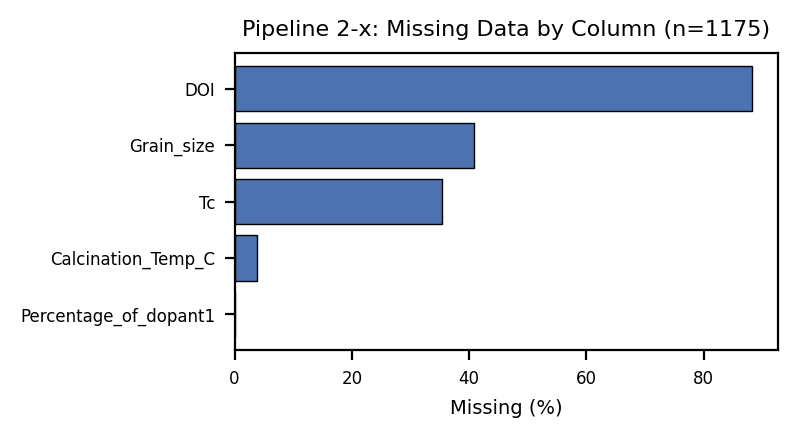

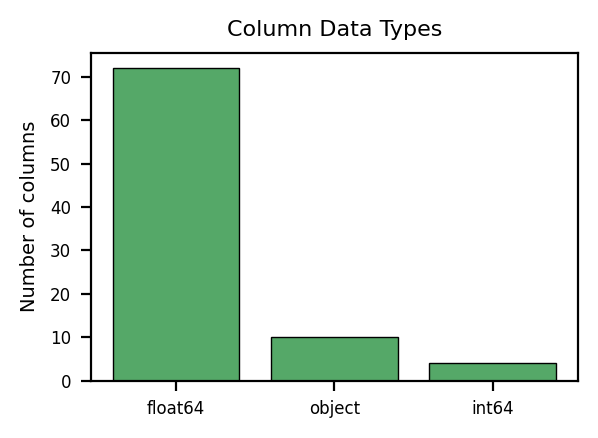

float64    72
object     10
int64       4
Name: count, dtype: int64


In [2]:
# ============================================================
# Chunk 2: Step 2 — Dataset stats
# ============================================================

plt.rcParams.update({
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'figure.dpi': 200,
})

print("="*60)
print("STEP 2: DATASET STATISTICS")
print("="*60)
print(f"\nTotal rows: {df_raw.shape[0]}")
print(f"Total columns: {df_raw.shape[1]}")
print(f"\nTarget variable: d33 (dtype: {df_raw['d33'].dtype})")

# --- Missingness overview, all columns ---
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(4, 2.2))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color='#4C72B0', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Missing (%)')
ax.set_title('Pipeline 2-x: Missing Data by Column (n=1175)')
plt.tight_layout()
plt.savefig('pipeline2x_missingness_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Dtype breakdown ---
dtype_counts = df_raw.dtypes.astype(str).value_counts()
fig, ax = plt.subplots(figsize=(3, 2.2))
ax.bar(dtype_counts.index, dtype_counts.values, color='#55A868', edgecolor='black', linewidth=0.5)
ax.set_ylabel('Number of columns')
ax.set_title('Column Data Types')
plt.tight_layout()
plt.savefig('pipeline2x_dtype_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print(dtype_counts)

STEP 3: DATA QUALITY CHECK

--- Missing values (columns with any NaN) ---
DOI                      1037
Grain_size                480
Tc                        415
Calcination_Temp_C         44
Percentage_of_dopant1       1
dtype: int64

--- Duplicate rows ---
Exact duplicate rows (all columns): 0
Duplicate rows ignoring 'No' identifier: 7

--- d33 range check ---
d33 <= 0: 0
d33 > 800: 21

--- Composition sanity: Ba+Ca ~1, Zr+Ti ~1 ---
Ba+Ca outside [0.98, 1.02]: 2
Zr+Ti outside [0.98, 1.02]: 42

--- Synthesis_method unique values ---
Synthesis_method
SOLID STATE                1026
SOL-GEL                      72
HYDROTHERMAL                 35
AUTOCOMBUSTION               12
POLYMERIC PRECURSOR          12
FREEZE CASTING                8
OXALATE PRECURSOR ROUTE       5
TAPE CASTING                  4
PECHINI METHOD                1
Name: count, dtype: int64

--- Journal_number unique count ---
Unique journals: 123

--- Dopant1 unique values (49) ---
dopant1
NIL                 408
C

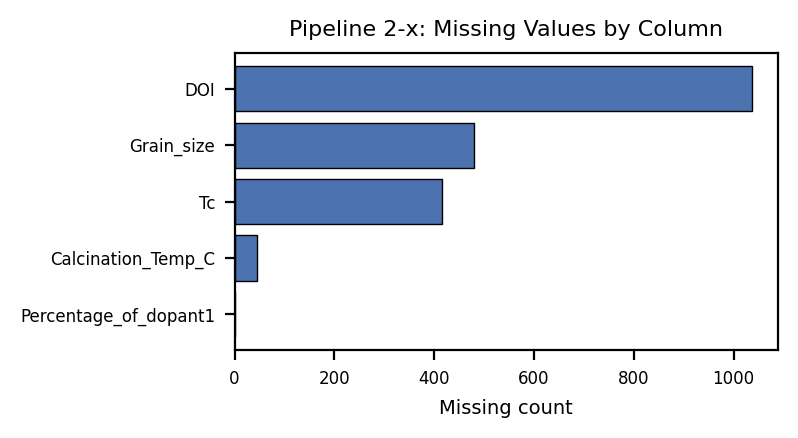

In [3]:
# ============================================================
# Chunk 3: Step 3 — Data quality check
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'figure.dpi': 200,
})

# Strip stray whitespace from theoretical descriptor column names (e.g. 'ANA ', ' t ')
df_raw.columns = df_raw.columns.str.strip()

print("="*60)
print("STEP 3: DATA QUALITY CHECK")
print("="*60)

missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n--- Missing values (columns with any NaN) ---")
print(missing)

print(f"\n--- Duplicate rows ---")
print(f"Exact duplicate rows (all columns): {df_raw.duplicated().sum()}")
print(f"Duplicate rows ignoring 'No' identifier: {df_raw.drop(columns=['No']).duplicated().sum()}")

print(f"\n--- d33 range check ---")
print(f"d33 <= 0: {(df_raw['d33'] <= 0).sum()}")
print(f"d33 > 800: {(df_raw['d33'] > 800).sum()}")

print(f"\n--- Composition sanity: Ba+Ca ~1, Zr+Ti ~1 ---")
a_site_sum = df_raw['Ba'] + df_raw['Ca']
b_site_sum = df_raw['Zr'] + df_raw['Ti']
print(f"Ba+Ca outside [0.98, 1.02]: {((a_site_sum < 0.98) | (a_site_sum > 1.02)).sum()}")
print(f"Zr+Ti outside [0.98, 1.02]: {((b_site_sum < 0.98) | (b_site_sum > 1.02)).sum()}")

print(f"\n--- Synthesis_method unique values ---")
print(df_raw['Synthesis_method'].value_counts(dropna=False))

print(f"\n--- Journal_number unique count ---")
print(f"Unique journals: {df_raw['Journal_number'].nunique()}")

# --- Dopant-specific checks (new for 2-x — dopants are retained as features here) ---
print(f"\n--- Dopant1 unique values ({df_raw['dopant1'].nunique()}) ---")
print(df_raw['dopant1'].value_counts(dropna=False).head(20))
print(f"\n--- Dopant2 unique values ({df_raw['dopant2'].nunique()}) ---")
print(df_raw['dopant2'].value_counts(dropna=False).head(20))
print(f"\n--- Percentage_of_dopant1 dtype: {df_raw['Percentage_of_dopant1'].dtype}, sample values ---")
print(df_raw['Percentage_of_dopant1'].unique()[:20])
print(f"\n--- Percentage_of_dopant2 dtype: {df_raw['Percentage_of_dopant2'].dtype}, sample values ---")
print(df_raw['Percentage_of_dopant2'].unique()[:20])

# --- Visualize missingness ---
fig, ax = plt.subplots(figsize=(4, 2.2))
ax.barh(missing.index[::-1], missing.values[::-1], color='#4C72B0', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Missing count')
ax.set_title('Pipeline 2-x: Missing Values by Column')
plt.tight_layout()
plt.savefig('pipeline2x_missing_step3.png', dpi=150, bbox_inches='tight')
plt.show()

COMPREHENSIVE MASTER DATASET AUDIT — PIPELINE 2-x

--- A-site unreconciled: 23 row(s) ---
      No                                   Compositions     Ba    Ca dopant1 dopant2 Percentage_of_dopant1 Percentage_of_dopant2 Journal_number
16    17       (Ba0.92Ca0.08)(Zr0.05Ti0.95)O3 +0.024 La  0.920  0.08      La     NIL                 0.024                     0             J6
674  675      (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3- 0.001(Y+Nb)  0.850  0.15       Y      Nb                   0.1                   0.1            J76
675  676      (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3- 0.001(Y+Nb)  0.850  0.15       Y      Nb                   0.1                   0.1            J76
676  677      (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3- 0.001(Y+Nb)  0.850  0.15       Y      Nb                   0.1                   0.1            J76
677  678      (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3- 0.001(Y+Nb)  0.850  0.15       Y      Nb                   0.1                   0.1            J76
678  679      (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3- 0.

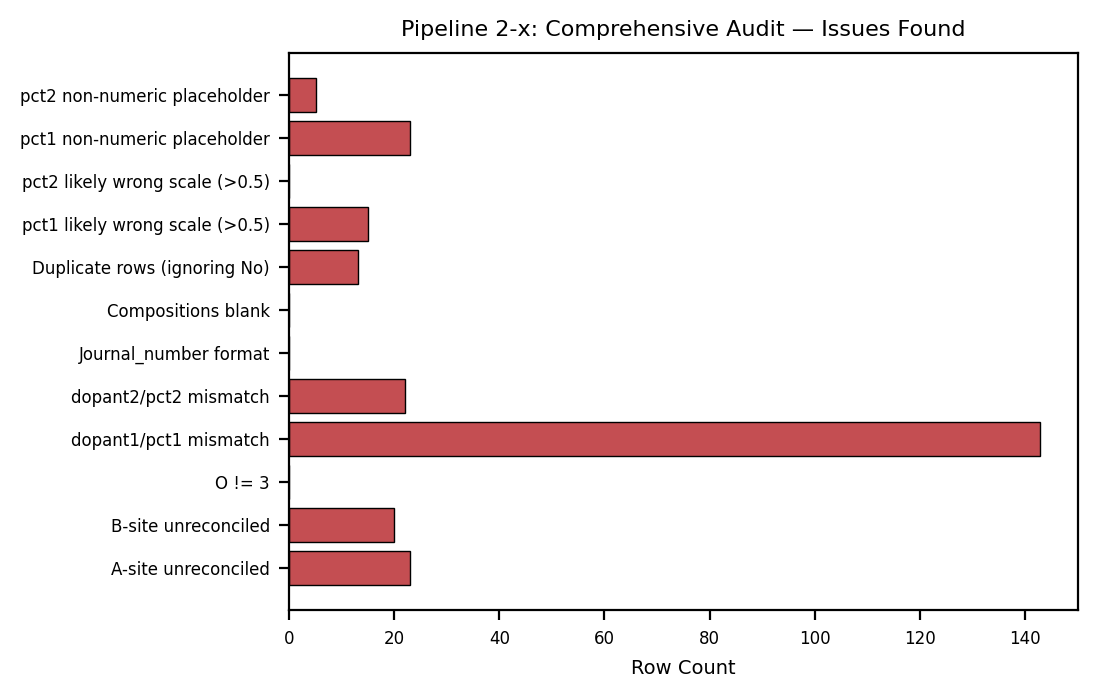

In [4]:
# ============================================================
# Chunk 4: Comprehensive Audit — full-dataset validation
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'figure.dpi': 200,
})

A_SITE_DOPANTS = ['Sr','La','Ce','Nd','Pr','Dy','Tb','Y','Yb','Tm','Bi','Li']
B_SITE_DOPANTS = ['Sn','Nb','Sb','Fe','Co','Cu','Zn','Al','B','Ta']

results = {}

def dopant_site_contribution(row, site_list):
    total = 0.0
    for d_col, p_col in [('dopant1','Percentage_of_dopant1'), ('dopant2','Percentage_of_dopant2')]:
        d = str(row[d_col]).strip()
        if d in site_list:
            try:
                total += float(row[p_col])
            except (ValueError, TypeError):
                pass
    return total

a_dopant = df_raw.apply(lambda r: dopant_site_contribution(r, A_SITE_DOPANTS), axis=1)
b_dopant = df_raw.apply(lambda r: dopant_site_contribution(r, B_SITE_DOPANTS), axis=1)

a_total = df_raw['Ba'] + df_raw['Ca'] + a_dopant
b_total = df_raw['Zr'] + df_raw['Ti'] + b_dopant

a_bad = (a_total < 0.98) | (a_total > 1.02)
b_bad = (b_total < 0.98) | (b_total > 1.02)
results['A-site unreconciled'] = df_raw.loc[a_bad, ['No','Compositions','Ba','Ca','dopant1','dopant2','Percentage_of_dopant1','Percentage_of_dopant2','Journal_number']]
results['B-site unreconciled'] = df_raw.loc[b_bad, ['No','Compositions','Zr','Ti','dopant1','dopant2','Percentage_of_dopant1','Percentage_of_dopant2','Journal_number']]

results['O != 3'] = df_raw.loc[df_raw['O'] != 3, ['No','Compositions','O','Journal_number']]

def dopant_pct_mismatch(row, d_col, p_col):
    d = str(row[d_col]).strip()
    try:
        p = float(row[p_col])
    except (ValueError, TypeError):
        return True
    if d == 'NIL' and p != 0:
        return True
    if d != 'NIL' and p == 0:
        return True
    return False

mismatch1 = df_raw.apply(lambda r: dopant_pct_mismatch(r, 'dopant1', 'Percentage_of_dopant1'), axis=1)
mismatch2 = df_raw.apply(lambda r: dopant_pct_mismatch(r, 'dopant2', 'Percentage_of_dopant2'), axis=1)
results['dopant1/pct1 mismatch'] = df_raw.loc[mismatch1, ['No','Compositions','dopant1','Percentage_of_dopant1','Journal_number']]
results['dopant2/pct2 mismatch'] = df_raw.loc[mismatch2, ['No','Compositions','dopant2','Percentage_of_dopant2','Journal_number']]

bad_journal = df_raw[~df_raw['Journal_number'].astype(str).str.match(r'^J\d+$')]
results['Journal_number format'] = bad_journal[['No','Compositions','Journal_number']]

results['Compositions blank'] = df_raw[df_raw['Compositions'].isna()]
results['Duplicate rows (ignoring No)'] = df_raw[df_raw.drop(columns=['No']).duplicated(keep=False)]

# --- New for 2-x: flag rows where Percentage_of_dopant looks like it's on the wrong scale ---
# (dopant fraction plausibly > 0.5 is almost certainly a percentage-integer, not a mole fraction)
def looks_like_percent_not_fraction(row, p_col):
    try:
        p = float(row[p_col])
    except (ValueError, TypeError):
        return False  # text placeholders caught separately below
    return p > 0.5

scale1 = df_raw.apply(lambda r: looks_like_percent_not_fraction(r, 'Percentage_of_dopant1'), axis=1)
scale2 = df_raw.apply(lambda r: looks_like_percent_not_fraction(r, 'Percentage_of_dopant2'), axis=1)
results['pct1 likely wrong scale (>0.5)'] = df_raw.loc[scale1, ['No','Compositions','dopant1','Percentage_of_dopant1','Journal_number']]
results['pct2 likely wrong scale (>0.5)'] = df_raw.loc[scale2, ['No','Compositions','dopant2','Percentage_of_dopant2','Journal_number']]

text1 = df_raw[pd.to_numeric(df_raw['Percentage_of_dopant1'], errors='coerce').isna() & df_raw['Percentage_of_dopant1'].notna()]
text2 = df_raw[pd.to_numeric(df_raw['Percentage_of_dopant2'], errors='coerce').isna() & df_raw['Percentage_of_dopant2'].notna()]
results['pct1 non-numeric placeholder'] = text1[['No','Compositions','dopant1','Percentage_of_dopant1','Journal_number']]
results['pct2 non-numeric placeholder'] = text2[['No','Compositions','dopant2','Percentage_of_dopant2','Journal_number']]

print("="*70)
print("COMPREHENSIVE MASTER DATASET AUDIT — PIPELINE 2-x")
print("="*70)
for name, res in results.items():
    print(f"\n--- {name}: {len(res)} row(s) ---")
    if len(res) > 0 and len(res) <= 50:
        print(res.to_string())
    elif len(res) > 50:
        print(f"(too many to print in full — {len(res)} rows, showing first 15)")
        print(res.head(15).to_string())

audit_counts = {k: len(v) for k, v in results.items()}
fig, ax = plt.subplots(figsize=(5.5, 3.5))
colors = ['#C44E52' if v > 0 else '#1B5E20' for v in audit_counts.values()]
ax.barh(list(audit_counts.keys()), list(audit_counts.values()), color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Row Count')
ax.set_title('Pipeline 2-x: Comprehensive Audit — Issues Found')
plt.tight_layout()
plt.savefig('pipeline2x_audit_summary.png', dpi=150, bbox_inches='tight')
plt.show()

DOPANT PERCENTAGE RECONCILIATION (v2 — corrected) — SUMMARY
Total doped dopant-slot rows checked: 895
flag
matches_ok                  483
no_text_check_available     246
MISMATCH_OTHER              135
non_numeric_placeholder      28
COMPOSITE_PHASE_FRACTION      3

Full table saved: pipeline2x_dopant_pct_reconciliation_v2.csv


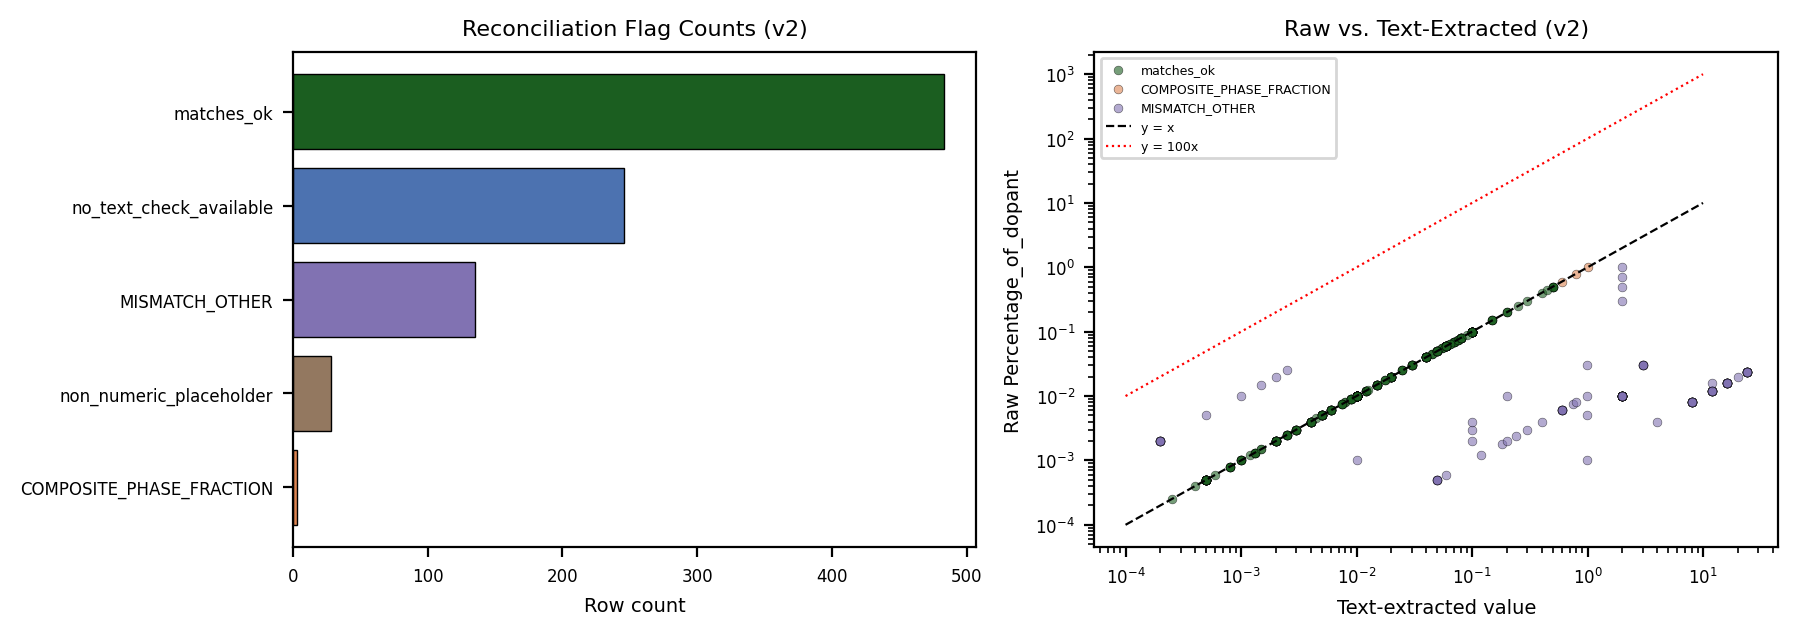


--- COMPOSITE_PHASE_FRACTION: 3 row(s) — needs your review ---
 No                                                         Compositions                     dopant raw_pct_str  text_extracted_value                               extraction_method  ratio_raw_over_text
481 0.94(Ba0.95Ca0.05)(Zr0.05Ti0.95)O3 - 0.6(Ba0.95Ca0.05Ti0.95Sn0.05O3) Ba0.95Ca0.05Ti0.95Sn0.05O3         0.6                   0.6 compound_num_before[Ba0.95Ca0.05Ti0.95Sn0.05O3]                  1.0
482 0.98(Ba0.95Ca0.05)(Zr0.05Ti0.95)O3 - 0.8(Ba0.95Ca0.05Ti0.95Sn0.05O3) Ba0.95Ca0.05Ti0.95Sn0.05O3         0.8                   0.8 compound_num_before[Ba0.95Ca0.05Ti0.95Sn0.05O3]                  1.0
483 0.99(Ba0.95Ca0.05)(Zr0.05Ti0.95)O3 - 1.0(Ba0.95Ca0.05Ti0.95Sn0.05O3) Ba0.95Ca0.05Ti0.95Sn0.05O3           1                   1.0 compound_num_before[Ba0.95Ca0.05Ti0.95Sn0.05O3]                  1.0

--- MISMATCH_OTHER: 135 row(s) — needs your review ---
  No                                           Compositions         

In [5]:
# ============================================================
# Chunk 5 (revised): Dopant Percentage Reconciliation — corrected extraction
# Fix: (1) for a bare element symbol, its own subscript is ALWAYS the number
#      immediately AFTER it (chemical notation) — never before, unless nothing
#      follows it directly, then fall back to "before". (2) skip labels with
#      internal fraction notation (e.g. 'Ta2/3') — they self-match falsely.
# Still makes NO changes to df_raw — output only.
# ============================================================

import re

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'figure.dpi': 200,
})

HOST_ELEMENTS = {'Ba', 'Ca', 'Zr', 'Ti'}

def extract_text_value(label, comp):
    label = str(label).strip()
    comp = str(comp)
    if label in ('NIL', 'nan', ''):
        return None, 'no_dopant'
    if '/' in label:
        return None, 'complex_site_fraction_label_skip'

    bare = re.sub(r'\s*\d*[+\-]$', '', label).strip()
    is_simple_element = bool(re.fullmatch(r'[A-Z][a-z]?', bare))

    if is_simple_element:
        sym = bare
        # Symbol's own subscript: immediately AFTER it, zero gap — try first, unambiguous
        m = re.search(re.escape(sym) + r'(\d[\d.]*)', comp)
        if m:
            try:
                return float(m.group(1)), f'tight_after[{sym}]'
            except ValueError:
                pass
        # Fallback: standalone additive term, coefficient immediately BEFORE it
        m = re.search(r'([\d.]+)' + re.escape(sym) + r'(?![a-zA-Z])', comp)
        if m:
            try:
                return float(m.group(1)), f'tight_before[{sym}]'
            except ValueError:
                pass
        return None, 'symbol_not_found_in_text'

    # Compound / oxide / complex-formula label (e.g. 'ZnO', 'CeO2', 'Ba(Cu0.5W0.5)O3')
    esc = re.escape(label)
    m = re.search(r'([\d.]+)[\s(+]*' + esc + r'(?![a-zA-Z])', comp)
    if m:
        try:
            return float(m.group(1)), f'compound_num_before[{label}]'
        except ValueError:
            pass
    m = re.search(esc + r'\s*([\d.]*\.?\d+)', comp)
    if m:
        try:
            return float(m.group(1)), f'compound_num_after[{label}]'
        except ValueError:
            pass
    sym_match = re.match(r'^[A-Z][a-z]?', label)
    if sym_match and sym_match.group(0) not in HOST_ELEMENTS:
        sym = sym_match.group(0)
        m = re.search(re.escape(sym) + r'(\d[\d.]*)', comp)
        if m:
            try:
                return float(m.group(1)), f'compound_symbol_fallback[{sym}]'
            except ValueError:
                pass
    return None, 'unparseable'

recon_rows = []
for idx, row in df_raw.iterrows():
    for d_col, p_col in [('dopant1', 'Percentage_of_dopant1'), ('dopant2', 'Percentage_of_dopant2')]:
        d = str(row[d_col]).strip()
        if d in ('NIL', 'nan', ''):
            continue
        raw_p_str = str(row[p_col]).strip()
        text_val, method = extract_text_value(d, row['Compositions'])
        try:
            raw_p = float(row[p_col])
            raw_is_numeric = True
        except (ValueError, TypeError):
            raw_p = np.nan
            raw_is_numeric = False

        ratio = (raw_p / text_val) if (raw_is_numeric and text_val not in (None, 0)) else np.nan

        if not raw_is_numeric:
            flag = 'non_numeric_placeholder'
        elif text_val is None:
            flag = 'no_text_check_available'
        elif abs(ratio - 100) < 15 and text_val <= 0.5:
            flag = 'CONFIRMED_x100_ERROR'
        elif abs(ratio - 1) < 0.15 and text_val <= 0.5:
            flag = 'matches_ok'
        elif abs(ratio - 1) < 0.15 and text_val > 0.5:
            flag = 'COMPOSITE_PHASE_FRACTION'
        else:
            flag = 'MISMATCH_OTHER'

        recon_rows.append({
            'No': row['No'], 'Compositions': row['Compositions'], 'Journal_number': row['Journal_number'],
            'dopant_col': d_col, 'dopant': d, 'raw_pct_str': raw_p_str, 'raw_pct': raw_p,
            'text_extracted_value': text_val, 'extraction_method': method,
            'ratio_raw_over_text': ratio, 'flag': flag,
            'suggested_value': (raw_p/100 if flag == 'CONFIRMED_x100_ERROR' else
                                 (raw_p if flag == 'matches_ok' else np.nan))
        })

recon_df = pd.DataFrame(recon_rows)
recon_df.to_csv('pipeline2x_dopant_pct_reconciliation_v2.csv', index=False)

print("="*70)
print("DOPANT PERCENTAGE RECONCILIATION (v2 — corrected) — SUMMARY")
print("="*70)
print(f"Total doped dopant-slot rows checked: {len(recon_df)}")
print(recon_df['flag'].value_counts().to_string())
print(f"\nFull table saved: pipeline2x_dopant_pct_reconciliation_v2.csv")

flag_counts = recon_df['flag'].value_counts()
colors_map = {
    'CONFIRMED_x100_ERROR': '#C44E52', 'matches_ok': '#1B5E20',
    'COMPOSITE_PHASE_FRACTION': '#DD8452', 'MISMATCH_OTHER': '#8172B2',
    'non_numeric_placeholder': '#937860', 'no_text_check_available': '#4C72B0',
    'complex_site_fraction_label_skip': '#CCCCCC',
}
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].barh(flag_counts.index[::-1], flag_counts.values[::-1],
             color=[colors_map.get(f, 'gray') for f in flag_counts.index[::-1]],
             edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Row count')
axes[0].set_title('Reconciliation Flag Counts (v2)')

plot_df = recon_df.dropna(subset=['raw_pct', 'text_extracted_value'])
plot_df = plot_df[(plot_df['raw_pct'] > 0) & (plot_df['text_extracted_value'] > 0)]
for flag, color in colors_map.items():
    sub = plot_df[plot_df['flag'] == flag]
    if len(sub) > 0:
        axes[1].scatter(sub['text_extracted_value'], sub['raw_pct'], s=10, alpha=0.6,
                         color=color, edgecolor='k', linewidth=0.2, label=flag)
lims = [1e-4, 10]
axes[1].plot(lims, lims, 'k--', linewidth=0.8, label='y = x')
axes[1].plot(lims, [100*l for l in lims], 'r:', linewidth=0.8, label='y = 100x')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Text-extracted value')
axes[1].set_ylabel('Raw Percentage_of_dopant')
axes[1].set_title('Raw vs. Text-Extracted (v2)')
axes[1].legend(fontsize=4.5, loc='upper left')
plt.tight_layout()
plt.savefig('pipeline2x_dopant_pct_reconciliation_v2.png', dpi=150, bbox_inches='tight')
plt.show()

for flag in ['COMPOSITE_PHASE_FRACTION', 'MISMATCH_OTHER']:
    sub = recon_df[recon_df['flag'] == flag]
    print(f"\n--- {flag}: {len(sub)} row(s) — needs your review ---")
    if len(sub) > 0:
        print(sub[['No','Compositions','dopant','raw_pct_str','text_extracted_value','extraction_method','ratio_raw_over_text']].to_string(index=False))

In [6]:
# ============================================================
# Chunk 5b: Export all flagged dopant % rows, grouped by Journal_number,
# for manual cross-check against source papers
# ============================================================

error_flags = ['CONFIRMED_x100_ERROR', 'MISMATCH_OTHER', 'COMPOSITE_PHASE_FRACTION', 'non_numeric_placeholder']
flagged = recon_df[recon_df['flag'].isin(error_flags)].copy()

# Collapse duplicate rows (same journal/dopant/composition/value repeated many times
# across replicate rows in the dataset) down to one line per unique issue
review_cols = ['Journal_number', 'Compositions', 'dopant_col', 'dopant',
                'raw_pct_str', 'text_extracted_value', 'extraction_method', 'flag']
dedup = flagged.drop_duplicates(subset=review_cols).copy()

# Count how many actual dataset rows each unique issue covers
counts = flagged.groupby(review_cols).size().reset_index(name='n_rows_affected')
review_table = dedup.merge(counts, on=review_cols, how='left')

# Sort by journal number numerically (J1, J2, ... not alphabetically J1, J10, J100...)
review_table['journal_num_sort'] = review_table['Journal_number'].str.extract(r'J(\d+)').astype(int)
review_table = review_table.sort_values(['journal_num_sort', 'dopant']).drop(columns='journal_num_sort')

review_table.to_csv('pipeline2x_dopant_pct_FOR_PAUL_REVIEW.csv', index=False)

print("="*70)
print(f"FLAGGED ROWS FOR MANUAL CROSS-CHECK — {len(review_table)} unique issues")
print(f"(covering {review_table['n_rows_affected'].sum()} dataset rows total)")
print("="*70)
print(f"\nBy flag type:")
print(review_table['flag'].value_counts().to_string())
print(f"\nSaved: pipeline2x_dopant_pct_FOR_PAUL_REVIEW.csv\n")

pd.set_option('display.max_rows', 200)
print(review_table[['Journal_number','Compositions','dopant','raw_pct_str',
                     'text_extracted_value','flag','n_rows_affected']].to_string(index=False))

FLAGGED ROWS FOR MANUAL CROSS-CHECK — 63 unique issues
(covering 138.0 dataset rows total)

By flag type:
flag
MISMATCH_OTHER              51
non_numeric_placeholder      9
COMPOSITE_PHASE_FRACTION     3

Saved: pipeline2x_dopant_pct_FOR_PAUL_REVIEW.csv

Journal_number                                                              Compositions                     dopant raw_pct_str  text_extracted_value                     flag  n_rows_affected
           J31                                (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3 - 1 wt% La2O3                      La2O3        0.01                2.0000           MISMATCH_OTHER             12.0
           J31                               (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3 - 1 wt% Li2CO3                     Li2CO3        0.01                2.0000           MISMATCH_OTHER             12.0
           J33                                              (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3                   TEXTURED           -                   NaN  non_numeric_placeh

In [7]:
# ============================================================
# Chunk 5c: Apply dopant percentage corrections + drop unusable rows
# - Divide by 100: all CONFIRMED_x100_ERROR rows + the Ba(Cu0.5W0.5)O3 cluster
#   (same x100 pattern, masked earlier by a missing decimal point in Compositions text)
# - Drop rows where the dopant amount is a non-numeric placeholder ('low', '-',
#   'LOW BCZT', etc.) — composite/blend systems, not simple host+dopant
# - Everything else is left untouched: matches_ok, no_text_check_available,
#   confirmed-fine false-positive clusters, and genuine remaining anomalies
#   that still need your own paper check
# ============================================================

print(f"Shape before dopant % corrections: {df_raw.shape}")

# --- 1. Correct: divide raw value by 100 ---
x100_mask = recon_df['flag'] == 'CONFIRMED_x100_ERROR'
ba_cuw_mask = recon_df['dopant'].str.contains(r'Ba\(Cu0\.5W0\.5\)O3', na=False) & (recon_df['flag'] == 'MISMATCH_OTHER') & (recon_df['raw_pct'] > 0.5)
to_correct = recon_df[x100_mask | ba_cuw_mask]

n_corrected = 0
for _, r in to_correct.iterrows():
    col = 'Percentage_of_dopant1' if r['dopant_col'] == 'dopant1' else 'Percentage_of_dopant2'
    row_idx = df_raw.index[df_raw['No'] == r['No']]
    if len(row_idx) > 0:
        df_raw.loc[row_idx, col] = r['raw_pct'] / 100
        n_corrected += 1

print(f"Corrected (÷100): {n_corrected} dopant-slot values across {to_correct['No'].nunique()} rows")

# Note: row 558 (Ba(Cu0.5W0.5)O3, J-series) had raw=1.6 where its neighbors in the
# same composition cluster show 1.2 — after ÷100 it becomes 0.016 vs neighbors' 0.012.
# Scale is now fixed; that residual value mismatch is a separate, minor inconsistency —
# flagging it here rather than silently smoothing it over.

# --- 2. Drop: non-numeric placeholder rows (composite/blend systems) ---
drop_rows = recon_df.loc[recon_df['flag'] == 'non_numeric_placeholder', 'No'].unique()
print(f"\nDropping {len(drop_rows)} rows with non-numeric dopant placeholders:")
print(df_raw[df_raw['No'].isin(drop_rows)][['No','Compositions','dopant1','dopant2','Journal_number']].to_string(index=False))

df_raw = df_raw[~df_raw['No'].isin(drop_rows)].reset_index(drop=True)
print(f"\nShape after corrections + drop: {df_raw.shape}")

# --- 3. What's left: genuine anomalies still needing your manual check ---
remaining = recon_df[recon_df['flag'].isin(['MISMATCH_OTHER', 'COMPOSITE_PHASE_FRACTION']) & ~ba_cuw_mask].copy()
false_positive_dopants = ['La2O3', 'Li2CO3', 'Tm3+']  # confirmed already-correct, no action needed
remaining = remaining[~remaining['dopant'].isin(false_positive_dopants)]
remaining = remaining[~((remaining['dopant'] == 'Dy0.5Tb0.5') & (remaining['No'].isin([1168, 1170, 1171])))]

remaining_dedup = remaining.drop_duplicates(subset=['Journal_number','Compositions','dopant','raw_pct_str','flag'])
remaining_dedup['journal_num_sort'] = remaining_dedup['Journal_number'].str.extract(r'J(\d+)').astype(int)
remaining_dedup = remaining_dedup.sort_values('journal_num_sort').drop(columns='journal_num_sort')

pd.set_option('display.max_rows', 100)
print("\n" + "="*70)
print(f"REMAINING ROWS NEEDING YOUR MANUAL CHECK — {len(remaining_dedup)} unique issues")
print("="*70)
print(remaining_dedup[['Journal_number','Compositions','dopant','raw_pct_str',
                        'text_extracted_value','ratio_raw_over_text','flag']].to_string(index=False))

remaining_dedup.to_csv('pipeline2x_dopant_pct_REMAINING_for_review.csv', index=False)
print(f"\nSaved: pipeline2x_dopant_pct_REMAINING_for_review.csv")

Shape before dopant % corrections: (1175, 86)
Corrected (÷100): 0 dopant-slot values across 0 rows

Dropping 23 rows with non-numeric dopant placeholders:
 No                                                              Compositions  dopant1 dopant2 Journal_number
259                                              (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3 TEXTURED     NIL            J33
585                                                0.65Bi1.05Fe2O3-0.35BaTiO3 LOW BCZT     NIL            J67
586      (0.99)(0.65Bi1.05Fe2O3-0.35BaTiO3)- 0.01(Ba0.85Ca0.15)(Zr0.1Ti0.9)O3 LOW BCZT     NIL            J67
587      (0.98)(0.65Bi1.05Fe2O3-0.35BaTiO3)- 0.02(Ba0.85Ca0.15)(Zr0.1Ti0.9)O3 LOW BCZT     NIL            J67
588      (0.97)(0.65Bi1.05Fe2O3-0.35BaTiO3)- 0.03(Ba0.85Ca0.15)(Zr0.1Ti0.9)O3 LOW BCZT     NIL            J67
751                                              (Ba0.85Ca0.15)(Zr0.1Ti0.9)O3   LNKNST     NIL            J88
752 (1 − x)(Li0.03Na0.5K0.47)(Nb0.92Sb0.05Ta0.03)O3–xBa0.85Ca0.15Zr0.1Ti0.9

In [8]:
# ============================================================
# Chunk 6: Drop exact duplicate rows (keep first occurrence)
# ============================================================

print(f"Shape before duplicate removal: {df_raw.shape}")
df_raw = df_raw.drop_duplicates(subset=[c for c in df_raw.columns if c != 'No'], keep='first').reset_index(drop=True)
print(f"Shape after duplicate removal:  {df_raw.shape}")
print(f"Rows removed: {1152 - df_raw.shape[0]}")

Shape before duplicate removal: (1152, 86)
Shape after duplicate removal:  (1146, 86)
Rows removed: 6


STEP 4: TARGET (d33) ANALYSIS

d33 missing values: 0

d33 distribution stats:
count    1146.000000
mean      335.761907
std       209.241707
min         5.000000
25%       200.000000
50%       325.000000
75%       440.000000
max      2950.000000
Name: d33, dtype: float64

d33 by unit type:
          count        mean         std  min    25%    50%    75%     max
d33_unit                                                                 
pC/N      928.0  306.021924  155.448710  5.0  195.0  310.0  413.5   780.0
pm/V      218.0  462.361468  328.489204  8.0  247.5  419.0  581.5  2950.0


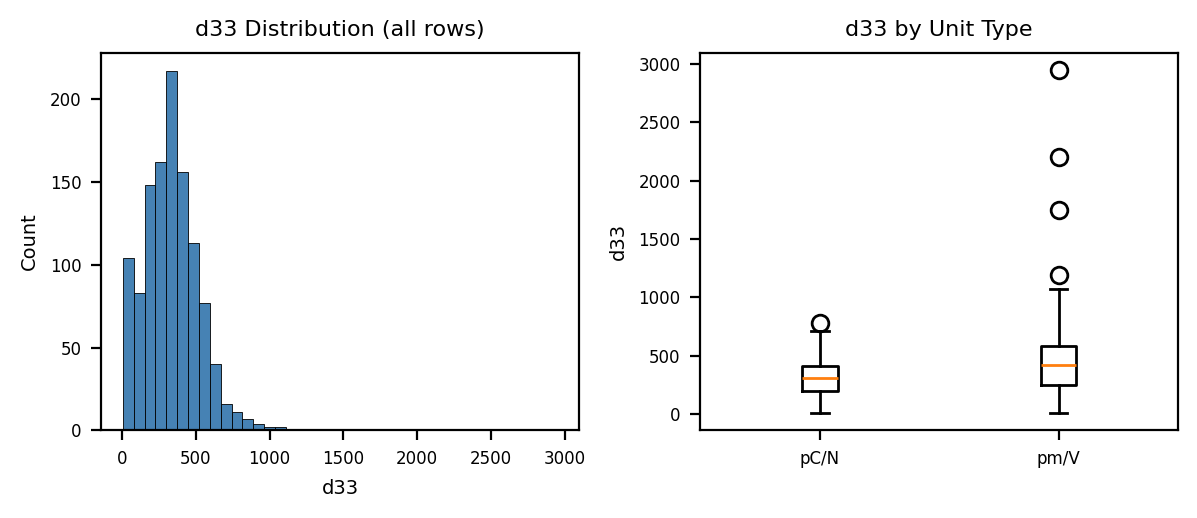

In [9]:
# ============================================================
# Chunk 7: Step 4 — Target (d33) analysis
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'figure.dpi': 200,
})

print("="*60)
print("STEP 4: TARGET (d33) ANALYSIS")
print("="*60)
print(f"\nd33 missing values: {df_raw['d33'].isnull().sum()}")
print(f"\nd33 distribution stats:")
print(df_raw['d33'].describe())
print(f"\nd33 by unit type:")
print(df_raw.groupby('d33_unit')['d33'].describe())

fig, axes = plt.subplots(1, 2, figsize=(6, 2.6))
axes[0].hist(df_raw['d33'], bins=40, color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].set_title('d33 Distribution (all rows)')
axes[0].set_xlabel('d33')
axes[0].set_ylabel('Count')

axes[1].boxplot([df_raw[df_raw['d33_unit']=='pC/N']['d33'], df_raw[df_raw['d33_unit']=='pm/V']['d33']],
                 labels=['pC/N', 'pm/V'])
axes[1].set_title('d33 by Unit Type')
axes[1].set_ylabel('d33')
plt.tight_layout()
plt.savefig('pipeline2x_d33_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Shape before outlier removal: (1146, 86)

Rows exceeding d33 > 800: 20
Unit breakdown of outliers:
d33_unit
pm/V    20
Name: count, dtype: int64

Outlier rows detail:
 No Journal_number    d33 d33_unit                               Compositions
382            J50  873.0     pm/V   (Ba0.94Ca0.06)(Zr0.05Ti0.95)O3-0.0050CuO
383            J50  868.0     pm/V   (Ba0.94Ca0.06)(Zr0.05Ti0.95)O3-0.0075CuO
384            J50  828.0     pm/V     (Ba0.94Ca0.06)(Zr0.05Ti0.95)O3-0.01CuO
499            J64 1750.0     pm/V  (Ba0.95Ca0.05)(Zr0.04Ti0.96)O3- 0.0025CuO
500            J64 2200.0     pm/V   (Ba0.95Ca0.05)(Zr0.04Ti0.96)O3- 0.005CuO
501            J64 2950.0     pm/V    (Ba0.95Ca0.05)(Zr0.04Ti0.96)O3- 0.01CuO
502            J64 1000.0     pm/V   (Ba0.95Ca0.05)(Zr0.04Ti0.96)O3- 0.025CuO
507            J64  850.0     pm/V    (Ba0.95Ca0.05)(Zr0.04Ti0.96)O3- 0.01CuO
930           J100 1189.0     pm/V (Ba0.85Ca0.15)0.999Ce0.0005)(Zr0.1Ti0.9)O3
931           J100  870.0     pm/V (Ba0.85Ca0.15)0.99

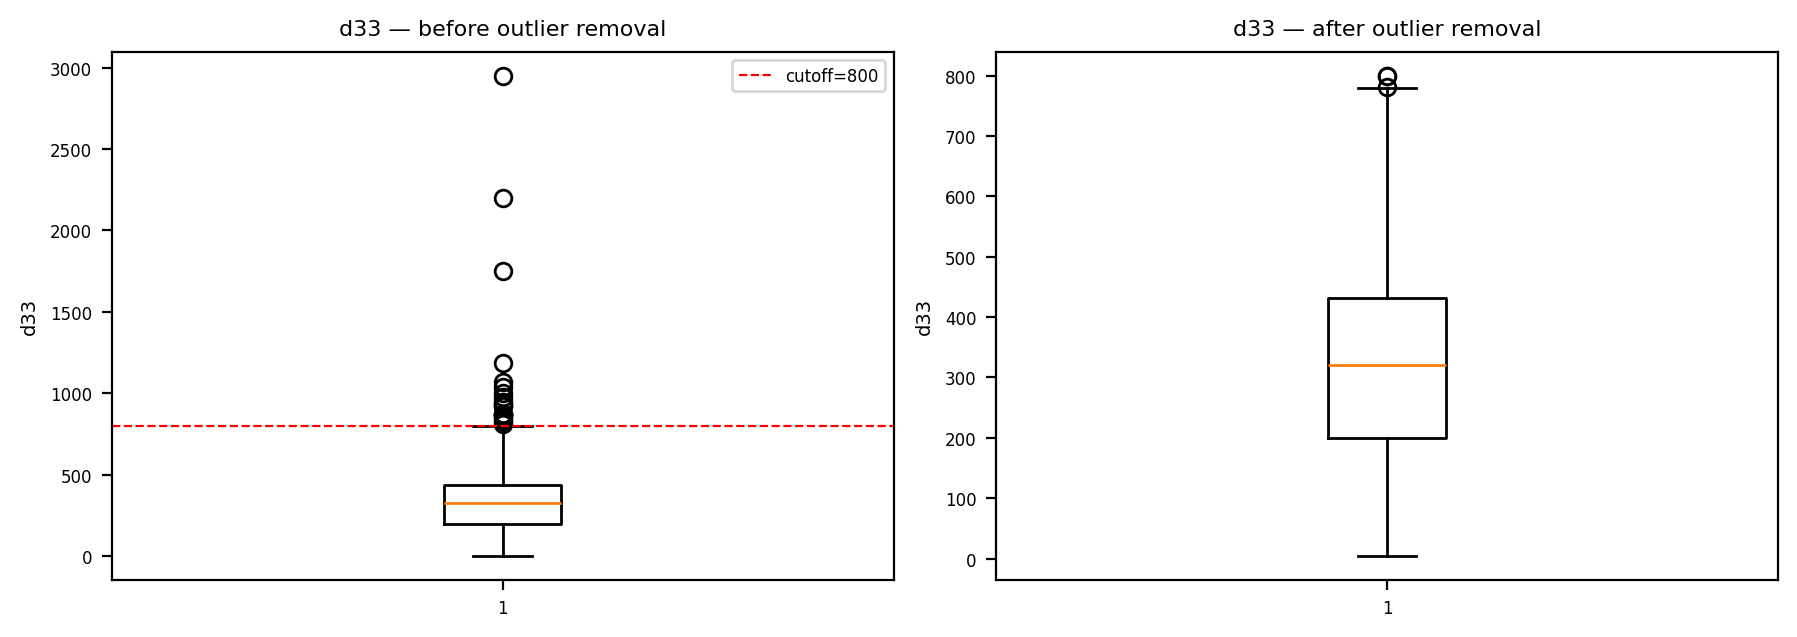


Shape after outlier removal: (1126, 86)

d33 stats after removal:
count    1126.000000
mean      321.517891
std       167.021501
min         5.000000
25%       200.000000
50%       320.000000
75%       432.000000
max       800.000000
Name: d33, dtype: float64


In [10]:
# ============================================================
# Chunk 8: Step 5 — Outlier detection & treatment
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6
})

print(f"Shape before outlier removal: {df_raw.shape}")

# --- Domain-justified cutoff: d33 > 800 is not physically plausible for
#     polycrystalline BCZT ceramics (consistent with Pipeline 1-x treatment) ---
outlier_mask = df_raw['d33'] > 800
outliers = df_raw[outlier_mask]

print(f"\nRows exceeding d33 > 800: {len(outliers)}")
print(f"Unit breakdown of outliers:")
print(outliers['d33_unit'].value_counts())

print(f"\nOutlier rows detail:")
print(outliers[['No','Journal_number','d33','d33_unit','Compositions']].to_string(index=False))

# --- Visualize before/after ---
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

axes[0].boxplot(df_raw['d33'].dropna(), vert=True)
axes[0].axhline(800, color='red', linestyle='--', linewidth=0.8, label='cutoff=800')
axes[0].set_title('d33 — before outlier removal')
axes[0].set_ylabel('d33')
axes[0].legend()

df_clean_preview = df_raw[~outlier_mask]
axes[1].boxplot(df_clean_preview['d33'].dropna(), vert=True)
axes[1].set_title('d33 — after outlier removal')
axes[1].set_ylabel('d33')

plt.tight_layout()
plt.show()

# --- Apply removal ---
df_raw = df_raw[~outlier_mask].reset_index(drop=True)
print(f"\nShape after outlier removal: {df_raw.shape}")
print(f"\nd33 stats after removal:")
print(df_raw['d33'].describe())

DEVIATION STARTS HERE


In [11]:
# ============================================================
# Chunk 9 [2-i]: Step 6 — Drop unnecessary columns (keep dopants + experimental)
# ============================================================
print(f"Shape before column drop: {df_raw.shape}")

theoretical_cols = df_raw.loc[:, 'ANA':'μ'].columns.tolist()   # 64 theoretical descriptor columns
drop_cols = theoretical_cols + ['DOI', 'Year']

df_raw = df_raw.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} columns (64 theoretical + DOI + Year)")
print(f"Shape after column drop: {df_raw.shape}")
print(f"\nRemaining columns:\n{df_raw.columns.tolist()}")

Shape before column drop: (1126, 86)
Dropped 66 columns (64 theoretical + DOI + Year)
Shape after column drop: (1126, 20)

Remaining columns:
['No', 'Compositions', 'Ba', 'Ca', 'Zr', 'Ti', 'O', 'd33', 'd33_unit', 'd33_measured_temperature', 'Calcination_Temp_C', 'Sintering_Temp_C', 'Grain_size', 'Tc', 'Synthesis_method', 'Journal_number', 'dopant1', 'dopant2', 'Percentage_of_dopant1', 'Percentage_of_dopant2']


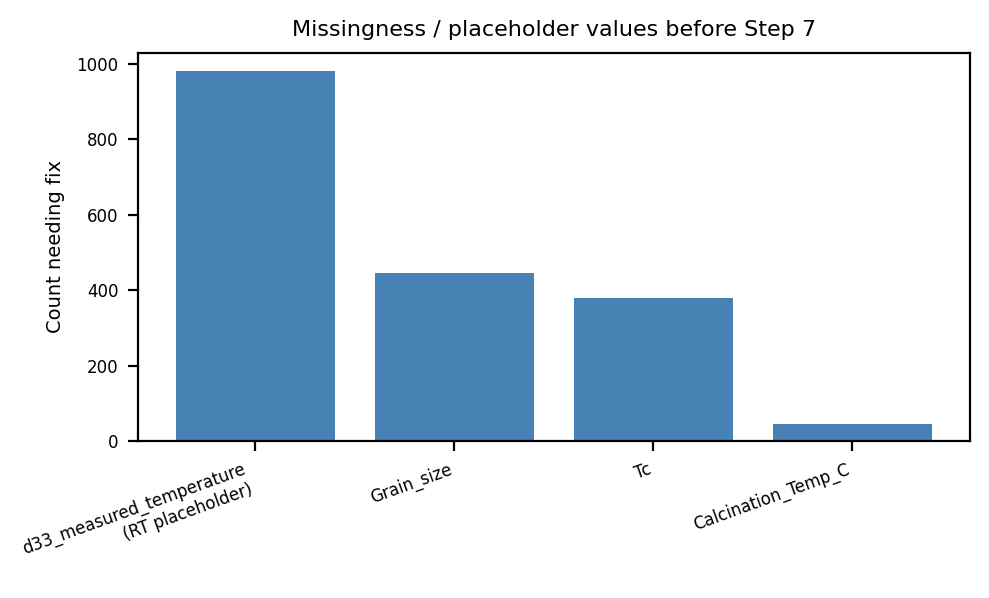

d33_measured_temperature converted to numeric. Missing after conversion: 0
Grain_size: imputed 446 missing values with median=13.00
Tc: imputed 380 missing values with median=92.00
Calcination_Temp_C: imputed 44 missing values with median=1200.00

Final missing value check:
d33_measured_temperature    0
Grain_size                  0
Tc                          0
Calcination_Temp_C          0
dtype: int64


In [12]:
# ============================================================
# Chunk 10: Step 7 — RT normalization + missing value imputation
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6
})

# --- Visualize missingness BEFORE any changes ---
impute_candidates = [c for c in ['Grain_size', 'Tc', 'Calcination_Temp_C'] if c in df_raw.columns]
miss_before = df_raw[['d33_measured_temperature'] + impute_candidates].isna().sum()
# d33_measured_temperature isn't NaN-missing, it's the 'RT' string — count that separately
rt_count = (df_raw['d33_measured_temperature'].astype(str) == 'RT').sum()

fig, ax = plt.subplots(figsize=(5, 3))
labels = ['d33_measured_temperature\n(RT placeholder)'] + impute_candidates
values = [rt_count] + [miss_before[c] for c in impute_candidates]
ax.bar(labels, values, color='steelblue')
ax.set_ylabel('Count needing fix')
ax.set_title('Missingness / placeholder values before Step 7')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# --- 1. RT -> 25°C (room temperature convention) ---
df_raw['d33_measured_temperature'] = df_raw['d33_measured_temperature'].replace('RT', 25)
df_raw['d33_measured_temperature'] = pd.to_numeric(df_raw['d33_measured_temperature'], errors='coerce')
print(f"d33_measured_temperature converted to numeric. Missing after conversion: {df_raw['d33_measured_temperature'].isna().sum()}")

# --- 2. Median imputation for processing columns (only if present in this pipeline) ---
for col in impute_candidates:
    n_missing = df_raw[col].isna().sum()
    if n_missing > 0:
        median_val = df_raw[col].median()
        df_raw[col] = df_raw[col].fillna(median_val)
        print(f"{col}: imputed {n_missing} missing values with median={median_val:.2f}")

print(f"\nFinal missing value check:\n{df_raw[['d33_measured_temperature'] + impute_candidates].isna().sum()}")

Shape before Step 8: (1126, 20)

Synthesis_method journal concentration:
                         count  nunique
Synthesis_method                       
AUTOCOMBUSTION              12        1
FREEZE CASTING               8        1
HYDROTHERMAL                35        1
OXALATE PRECURSOR ROUTE      5        1
PECHINI METHOD               1        1
TAPE CASTING                 4        1
POLYMERIC PRECURSOR         12        2
SOL-GEL                     72        9
SOLID STATE                977      102

Bucketed to OTHER (< 3 journals): ['AUTOCOMBUSTION', 'FREEZE CASTING', 'HYDROTHERMAL', 'OXALATE PRECURSOR ROUTE', 'PECHINI METHOD', 'POLYMERIC PRECURSOR', 'TAPE CASTING']
Added one-hot columns: ['synth_OTHER', 'synth_SOL-GEL', 'synth_SOLID STATE']

d33_unit value counts (dropping):
d33_unit
pC/N    928
pm/V    198
Name: count, dtype: int64

O unique values: [3] -> dropping (constant)

Engineered features added: ['A_site_ratio', 'B_site_ratio', 'thermal_budget']
       A_site_ratio 

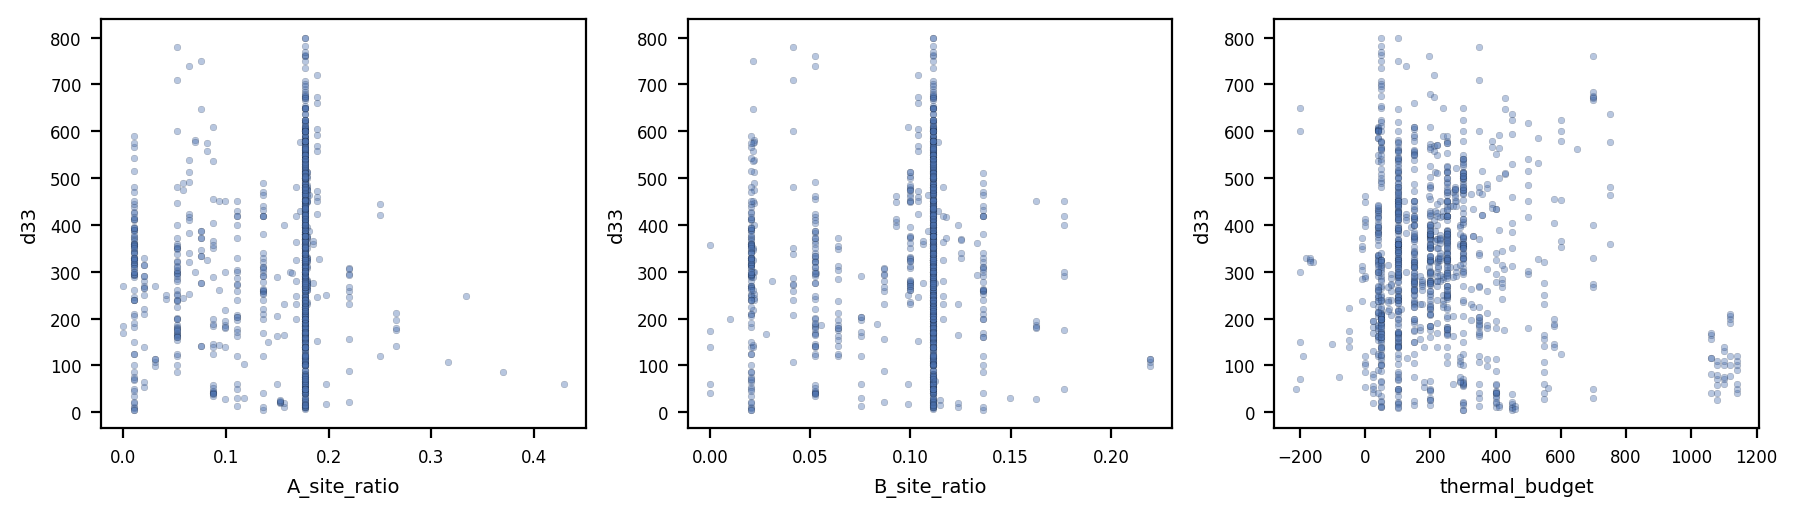


Shape after Step 8: (1126, 23)


In [13]:
# ============================================================
# Chunk 11 (revised): Step 8 — Categorical encoding + feature engineering
# Synthesis_method bucketing rule added: same journal-concentration guard as
# the dopant fix — a method must span >=3 distinct journals to get its own
# one-hot column, otherwise it acts as a hidden journal-ID under GroupKFold.
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6
})

print(f"Shape before Step 8: {df_raw.shape}")

if 'Synthesis_method' in df_raw.columns:
    grp = df_raw.groupby('Synthesis_method')['Journal_number'].agg(['count','nunique'])
    print(f"\nSynthesis_method journal concentration:\n{grp.sort_values('nunique').to_string()}")
    MIN_JOURNALS = 3
    safe_methods = grp[grp['nunique'] >= MIN_JOURNALS].index
    print(f"\nBucketed to OTHER (< {MIN_JOURNALS} journals): {[m for m in grp.index if m not in safe_methods]}")
    df_raw['Synthesis_method_grouped'] = df_raw['Synthesis_method'].apply(lambda x: x if x in safe_methods else 'OTHER')
    synth_dummies = pd.get_dummies(df_raw['Synthesis_method_grouped'], prefix='synth')
    df_raw = pd.concat([df_raw, synth_dummies], axis=1)
    df_raw = df_raw.drop(columns=['Synthesis_method', 'Synthesis_method_grouped'])
    print(f"Added one-hot columns: {list(synth_dummies.columns)}")

print(f"\nd33_unit value counts (dropping):")
print(df_raw['d33_unit'].value_counts())
df_raw = df_raw.drop(columns=['d33_unit'])

print(f"\nO unique values: {df_raw['O'].unique()} -> dropping (constant)")
df_raw = df_raw.drop(columns=['O'])

df_raw['A_site_ratio'] = df_raw['Ca'] / df_raw['Ba']
df_raw['B_site_ratio'] = df_raw['Zr'] / df_raw['Ti']
if 'Calcination_Temp_C' in df_raw.columns and 'Sintering_Temp_C' in df_raw.columns:
    df_raw['thermal_budget'] = df_raw['Sintering_Temp_C'] - df_raw['Calcination_Temp_C']

eng_cols = [c for c in ['A_site_ratio','B_site_ratio','thermal_budget'] if c in df_raw.columns]
print(f"\nEngineered features added: {eng_cols}")
print(df_raw[eng_cols].describe())

fig, axes = plt.subplots(1, len(eng_cols), figsize=(3*len(eng_cols), 2.6))
if len(eng_cols) == 1: axes = [axes]
for ax, feat in zip(axes, eng_cols):
    ax.scatter(df_raw[feat], df_raw['d33'], alpha=0.4, s=6, color='#4C72B0', edgecolor='k', linewidth=0.1)
    ax.set_xlabel(feat); ax.set_ylabel('d33')
plt.tight_layout()
plt.show()

print(f"\nShape after Step 8: {df_raw.shape}")

                 pearson  spearman  mutual_info
thermal_budget -0.137702 -0.013599     0.279864
A_site_ratio    0.095972  0.139295     0.162437
B_site_ratio    0.050757  0.030926     0.115636

For comparison — raw Zr: pearson=0.0541, mutual_info=0.1094


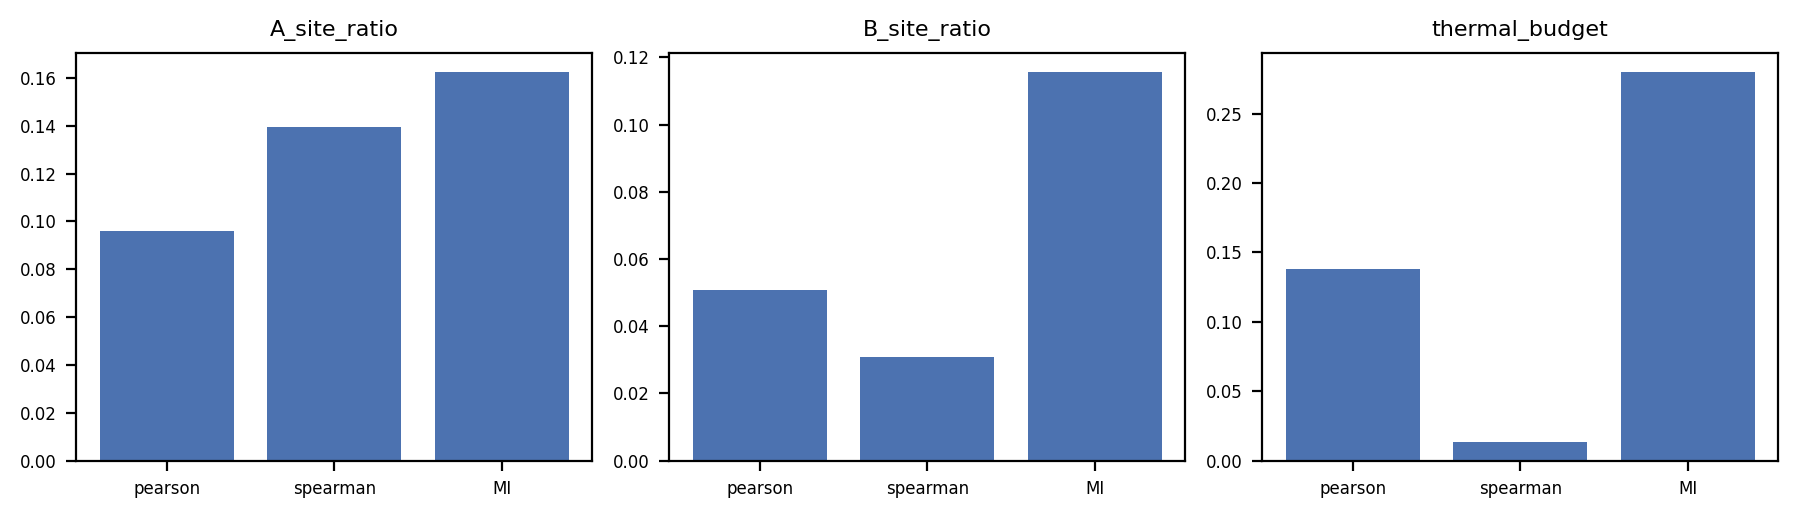


Kept B_site_ratio (MI=0.1156 > raw Zr MI=0.1094) — beats raw Zr here, unlike 1-iii

Final shape after Step 8: (1126, 23)


In [14]:
# ============================================================
# Chunk 12: Step 8b — Evaluate engineered features (keep or drop B_site_ratio)
# ============================================================

from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6
})

eng_cols = [c for c in ['A_site_ratio','B_site_ratio','thermal_budget'] if c in df_raw.columns]
X_new = df_raw[eng_cols].astype(float)
y = df_raw['d33'].astype(float)

pearson_new = X_new.corrwith(y)
spearman_new = pd.Series({c: spearmanr(X_new[c], y)[0] for c in eng_cols}, name='spearman')
mi_new = pd.Series(mutual_info_regression(X_new, y, random_state=42), index=eng_cols, name='mutual_info')

# Compare B_site_ratio against raw Zr directly
zr_pearson = df_raw['Zr'].astype(float).corr(y)
zr_mi = mutual_info_regression(df_raw[['Zr']].astype(float), y, random_state=42)[0]

check = pd.DataFrame({'pearson': pearson_new, 'spearman': spearman_new, 'mutual_info': mi_new})
check = check.sort_values('mutual_info', ascending=False)
print(check.to_string())
print(f"\nFor comparison — raw Zr: pearson={zr_pearson:.4f}, mutual_info={zr_mi:.4f}")

fig, axes = plt.subplots(1, len(eng_cols), figsize=(3*len(eng_cols), 2.6))
if len(eng_cols) == 1: axes = [axes]
for ax, feat in zip(axes, eng_cols):
    ax.bar(['pearson','spearman','MI'], [abs(pearson_new[feat]), abs(spearman_new[feat]), mi_new[feat]], color='#4C72B0')
    ax.set_title(feat)
plt.tight_layout()
plt.show()

# --- Drop B_site_ratio only if it doesn't clearly beat raw Zr (same logic as 1-iii) ---
if mi_new['B_site_ratio'] <= zr_mi:
    df_raw = df_raw.drop(columns=['B_site_ratio'])
    print(f"\nDropped B_site_ratio (MI={mi_new['B_site_ratio']:.4f} <= raw Zr MI={zr_mi:.4f})")
else:
    print(f"\nKept B_site_ratio (MI={mi_new['B_site_ratio']:.4f} > raw Zr MI={zr_mi:.4f}) — beats raw Zr here, unlike 1-iii")

print(f"\nFinal shape after Step 8: {df_raw.shape}")

In [15]:
# ============================================================
# Chunk 13 (revised): Step 9 — Dopant encoding
# Bucket rule updated: a species must appear in >=5 rows AND across >=3 distinct
# journals to get its own one-hot column. A dopant tied to <3 journals can never
# be both trained and validated under GroupKFold — it acts as a hidden journal-ID
# and corrupts leakage-safe CV (found via 2-ii's honest R2 collapsing to negative).
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6
})

print(f"Shape before dopant encoding: {df_raw.shape}")
print(f"\ndopant1 unique species: {df_raw['dopant1'].nunique()}")
print(f"dopant2 unique species: {df_raw['dopant2'].nunique()}")

MIN_ROWS = 5
MIN_JOURNALS = 3

def get_safe_species(col):
    grp = df_raw.groupby(col)['Journal_number'].agg(['count', 'nunique'])
    safe = grp[(grp['count'] >= MIN_ROWS) & (grp['nunique'] >= MIN_JOURNALS)].index
    unsafe = grp[~((grp['count'] >= MIN_ROWS) & (grp['nunique'] >= MIN_JOURNALS))]
    return set(safe), unsafe

d1_safe, d1_unsafe = get_safe_species('dopant1')
d2_safe, d2_unsafe = get_safe_species('dopant2')

print(f"\ndopant1 species bucketed to OTHER (too rare or journal-concentrated): {len(d1_unsafe)}")
print(d1_unsafe.to_string())
print(f"\ndopant2 species bucketed to OTHER: {len(d2_unsafe)}")
print(d2_unsafe.to_string())

df_raw['dopant1_grouped'] = df_raw['dopant1'].apply(lambda x: x if x in d1_safe else 'OTHER')
df_raw['dopant2_grouped'] = df_raw['dopant2'].apply(lambda x: x if x in d2_safe else 'OTHER')

d1_dummies = pd.get_dummies(df_raw['dopant1_grouped'], prefix='dopant1')
d2_dummies = pd.get_dummies(df_raw['dopant2_grouped'], prefix='dopant2')
df_raw = pd.concat([df_raw, d1_dummies, d2_dummies], axis=1)
df_raw = df_raw.drop(columns=['dopant1', 'dopant2', 'dopant1_grouped', 'dopant2_grouped'])

for col in ['Percentage_of_dopant1', 'Percentage_of_dopant2']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce').fillna(0)

print(f"\ndopant1 one-hot columns kept: {len(d1_dummies.columns)} -> {list(d1_dummies.columns)}")
print(f"dopant2 one-hot columns kept: {len(d2_dummies.columns)} -> {list(d2_dummies.columns)}")
print(f"\nShape after dopant encoding: {df_raw.shape}")

Shape before dopant encoding: (1126, 23)

dopant1 unique species: 46
dopant2 unique species: 13

dopant1 species bucketed to OTHER (too rare or journal-concentrated): 40
                            count  nunique
dopant1                                   
(Bi0.50Li0.50)TiO3              5        1
AlN                            16        1
B2O3                            5        1
Ba(Cu0.5W0.5)O3                72        1
Ba0.95Ca0.05Ti0.95Sn0.05O3      5        1
BaTi0.89Sn0.11O3               27        1
BaTiO3                          7        1
Bi                              5        2
Bi(Mg0.5Sn0.5)O3                5        1
Bi2O3                          15        1
CaCl2                          12        1
Co                              3        1
CoO                             8        1
Cu                              1        1
Cu 2+                          18        1
Dy                              7        1
Dy0.5Tb0.5                      4        1
Dy2O3        

In [16]:
# ============================================================
# Chunk 14: Step 10 — Pre-modeling sanity check
# ============================================================

print(f"Current shape: {df_raw.shape}")

print(f"\nColumn dtypes summary:")
print(df_raw.dtypes.value_counts())

print(f"\nNon-numeric columns remaining (should only be ID/text columns, not features):")
non_numeric = df_raw.select_dtypes(exclude=[np.number, bool]).columns.tolist()
print(non_numeric)

print(f"\nAny NaN remaining anywhere:")
nan_counts = df_raw.isna().sum()
print(nan_counts[nan_counts > 0] if nan_counts.sum() > 0 else "None")

print(f"\nAny infinite values (numeric columns only):")
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df_raw[numeric_cols]).sum()
print(inf_counts[inf_counts > 0] if inf_counts.sum() > 0 else "None")

print(f"\nJournal_number unique count (for group-based splitting later): {df_raw['Journal_number'].nunique()}")

Current shape: (1126, 30)

Column dtypes summary:
float64    13
bool       12
int64       3
object      2
Name: count, dtype: int64

Non-numeric columns remaining (should only be ID/text columns, not features):
['Compositions', 'Journal_number']

Any NaN remaining anywhere:
None

Any infinite values (numeric columns only):
None

Journal_number unique count (for group-based splitting later): 119


Candidate features going into selection: 26

TOP 25 FEATURES — COMPOSITE IMPORTANCE (5 methods averaged)
                          pearson_norm  spearman_norm   mi_norm  tree_norm  perm_norm  composite_score
Grain_size                    0.793118       1.000000  0.753752   1.000000   1.000000         0.909374
Tc                            0.837517       0.676494  0.939192   0.996196   0.946247         0.879129
Sintering_Temp_C              0.891925       0.833652  0.811872   0.671055   0.943540         0.830409
Calcination_Temp_C            1.000000       0.468273  0.839001   0.497294   0.334612         0.627836
thermal_budget                0.553358       0.000000  1.000000   0.468730   0.238277         0.452073
d33_measured_temperature      0.627574       0.251888  0.156329   0.384774   0.726946         0.429502
synth_OTHER                   0.954466       0.820912  0.051479   0.131504   0.068014         0.405275
Ca                            0.386604       0.448023  0.533983   0.166

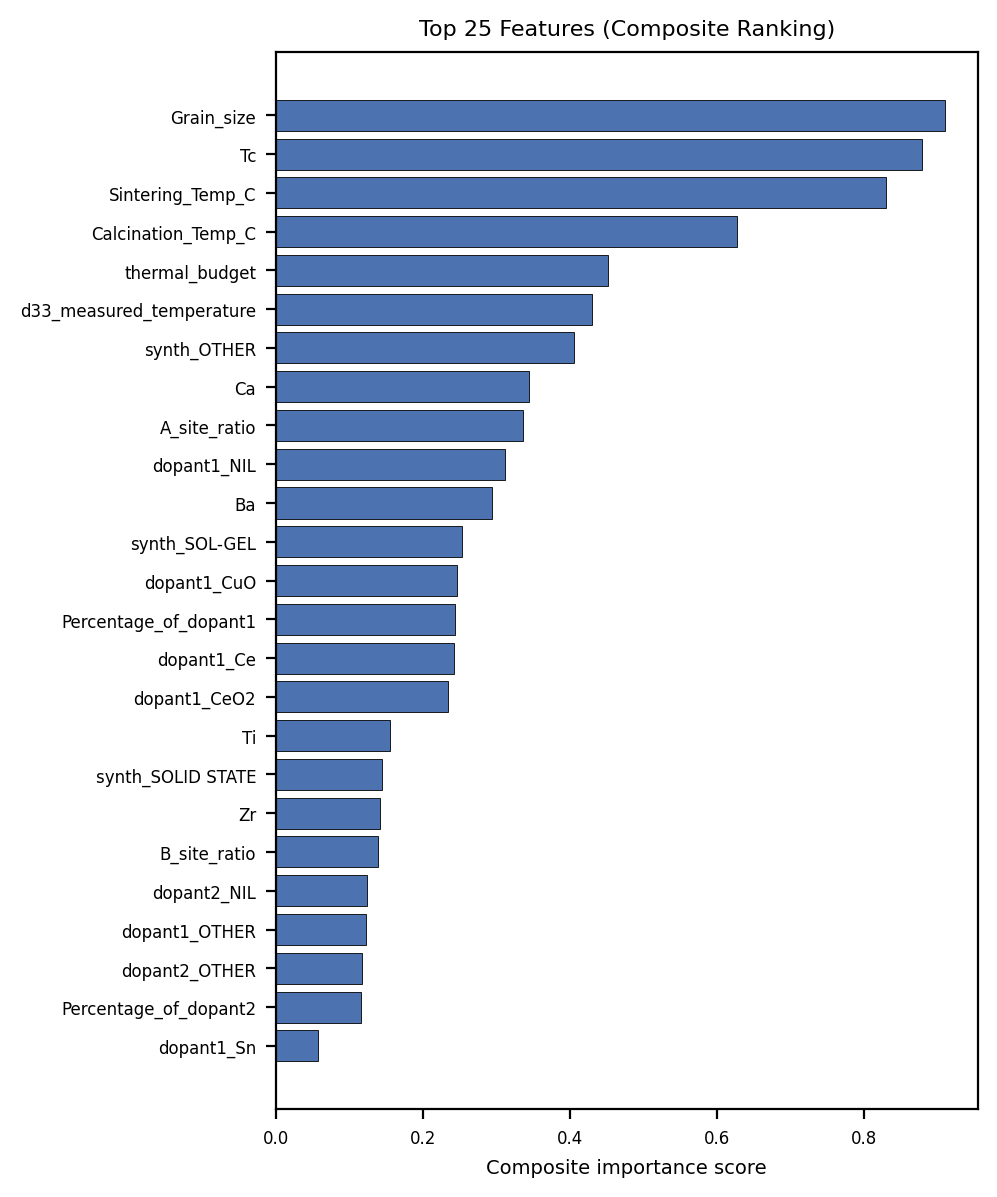

In [17]:
# ============================================================
# Chunk 15: Step 11a — Composite feature importance
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6
})

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr, pearsonr

exclude_cols = ['No', 'Compositions', 'Journal_number', 'd33']
candidate_feats = [c for c in df_raw.columns if c not in exclude_cols]
print(f"Candidate features going into selection: {len(candidate_feats)}")

X = df_raw[candidate_feats].astype(float)
y = df_raw['d33'].astype(float)

pearson = pd.Series({c: pearsonr(X[c], y)[0] for c in candidate_feats})
spearman = pd.Series({c: spearmanr(X[c], y)[0] for c in candidate_feats})
mi = pd.Series(mutual_info_regression(X, y, random_state=42), index=candidate_feats)

et = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
et.fit(X, y)
tree_imp = pd.Series(et.feature_importances_, index=candidate_feats)

perm = permutation_importance(et, X, y, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=candidate_feats)

def normalize(s):
    s_abs = s.abs()
    return (s_abs - s_abs.min()) / (s_abs.max() - s_abs.min())

composite = pd.DataFrame({
    'pearson_norm': normalize(pearson),
    'spearman_norm': normalize(spearman),
    'mi_norm': normalize(mi),
    'tree_norm': normalize(tree_imp),
    'perm_norm': normalize(perm_imp),
})
composite['composite_score'] = composite.mean(axis=1)
composite = composite.sort_values('composite_score', ascending=False)

print("\n" + "="*70)
print("TOP 25 FEATURES — COMPOSITE IMPORTANCE (5 methods averaged)")
print("="*70)
print(composite.head(25).to_string())

top25 = composite.head(25)
fig, ax = plt.subplots(figsize=(5, 6))
ax.barh(top25.index[::-1], top25['composite_score'].values[::-1], color='#4C72B0', edgecolor='black', linewidth=0.3)
ax.set_xlabel('Composite importance score')
ax.set_title('Top 25 Features (Composite Ranking)')
plt.tight_layout()
plt.show()

TOP 25 FEATURES — FINAL COMPOSITE (6 methods: Pearson+Spearman+MI+tree+permutation+SHAP)
                          pearson_norm  spearman_norm   mi_norm  tree_norm  perm_norm  shap_norm  composite_score
Grain_size                    0.793118       1.000000  0.753752   1.000000   1.000000   0.981039         0.921318
Tc                            0.837517       0.676494  0.939192   0.996196   0.946247   0.853848         0.874916
Sintering_Temp_C              0.891925       0.833652  0.811872   0.671055   0.943540   1.000000         0.858674
Calcination_Temp_C            1.000000       0.468273  0.839001   0.497294   0.334612   0.460844         0.600004
d33_measured_temperature      0.627574       0.251888  0.156329   0.384774   0.726946   0.446205         0.432286
thermal_budget                0.553358       0.000000  1.000000   0.468730   0.238277   0.283054         0.423903
synth_OTHER                   0.954466       0.820912  0.051479   0.131504   0.068014   0.191430         0.369634

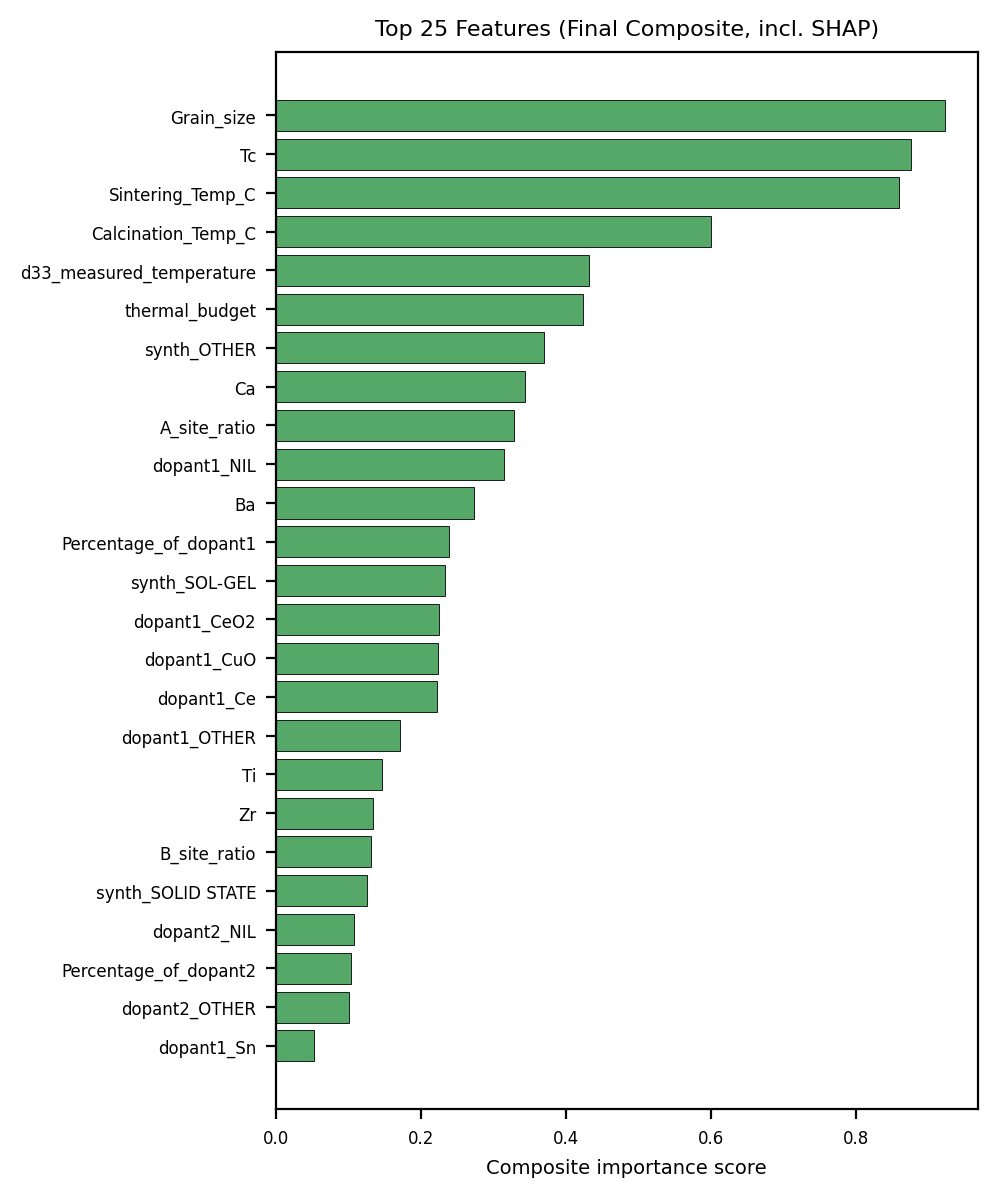

In [18]:
# ============================================================
# Chunk 16: Step 11b — SHAP importance, added to composite
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6
})

import shap

# Reuse the ExtraTrees model already fit in Chunk 15
explainer = shap.TreeExplainer(et)
shap_values = explainer.shap_values(X)
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=candidate_feats)

composite['shap_norm'] = normalize(shap_imp)
composite['composite_score'] = composite[['pearson_norm','spearman_norm','mi_norm','tree_norm','perm_norm','shap_norm']].mean(axis=1)
composite = composite.sort_values('composite_score', ascending=False)

print("="*70)
print("TOP 25 FEATURES — FINAL COMPOSITE (6 methods: Pearson+Spearman+MI+tree+permutation+SHAP)")
print("="*70)
print(composite[['pearson_norm','spearman_norm','mi_norm','tree_norm','perm_norm','shap_norm','composite_score']].head(25).to_string())

top25 = composite.head(25)
fig, ax = plt.subplots(figsize=(5, 6))
ax.barh(top25.index[::-1], top25['composite_score'].values[::-1], color='#55A868', edgecolor='black', linewidth=0.3)
ax.set_xlabel('Composite importance score')
ax.set_title('Top 25 Features (Final Composite, incl. SHAP)')
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# Chunk 17: Step 12a — Select top-16 candidate features
# ============================================================

top16 = composite.head(16).index.tolist()
print("Top 16 candidates going into VIF pruning:")
for i, f in enumerate(top16, 1):
    print(f"  {i}. {f}  (composite={composite.loc[f,'composite_score']:.4f})")

Top 16 candidates going into VIF pruning:
  1. Grain_size  (composite=0.9213)
  2. Tc  (composite=0.8749)
  3. Sintering_Temp_C  (composite=0.8587)
  4. Calcination_Temp_C  (composite=0.6000)
  5. d33_measured_temperature  (composite=0.4323)
  6. thermal_budget  (composite=0.4239)
  7. synth_OTHER  (composite=0.3696)
  8. Ca  (composite=0.3430)
  9. A_site_ratio  (composite=0.3286)
  10. dopant1_NIL  (composite=0.3145)
  11. Ba  (composite=0.2735)
  12. Percentage_of_dopant1  (composite=0.2392)
  13. synth_SOL-GEL  (composite=0.2334)
  14. dopant1_CeO2  (composite=0.2247)
  15. dopant1_CuO  (composite=0.2235)
  16. dopant1_Ce  (composite=0.2220)


Pre-excluded (structurally redundant, present in this pipeline's top16): ['thermal_budget']
Clean candidate pool (15 features): ['Grain_size', 'Tc', 'Sintering_Temp_C', 'Calcination_Temp_C', 'd33_measured_temperature', 'synth_OTHER', 'Ca', 'A_site_ratio', 'dopant1_NIL', 'Ba', 'Percentage_of_dopant1', 'synth_SOL-GEL', 'dopant1_CeO2', 'dopant1_CuO', 'dopant1_Ce']

INITIAL VIF (15-feature pool)
                     feature         VIF
0                         Ca  565.340243
1               A_site_ratio  315.363442
2                         Ba  311.121910
3         Calcination_Temp_C    2.501551
4                synth_OTHER    2.099371
5                         Tc    1.625767
6              synth_SOL-GEL    1.528539
7   d33_measured_temperature    1.470848
8                dopant1_NIL    1.464353
9                dopant1_CuO    1.362239
10          Sintering_Temp_C    1.329430
11                dopant1_Ce    1.156017
12                Grain_size    1.149271
13              dopant1_CeO2   

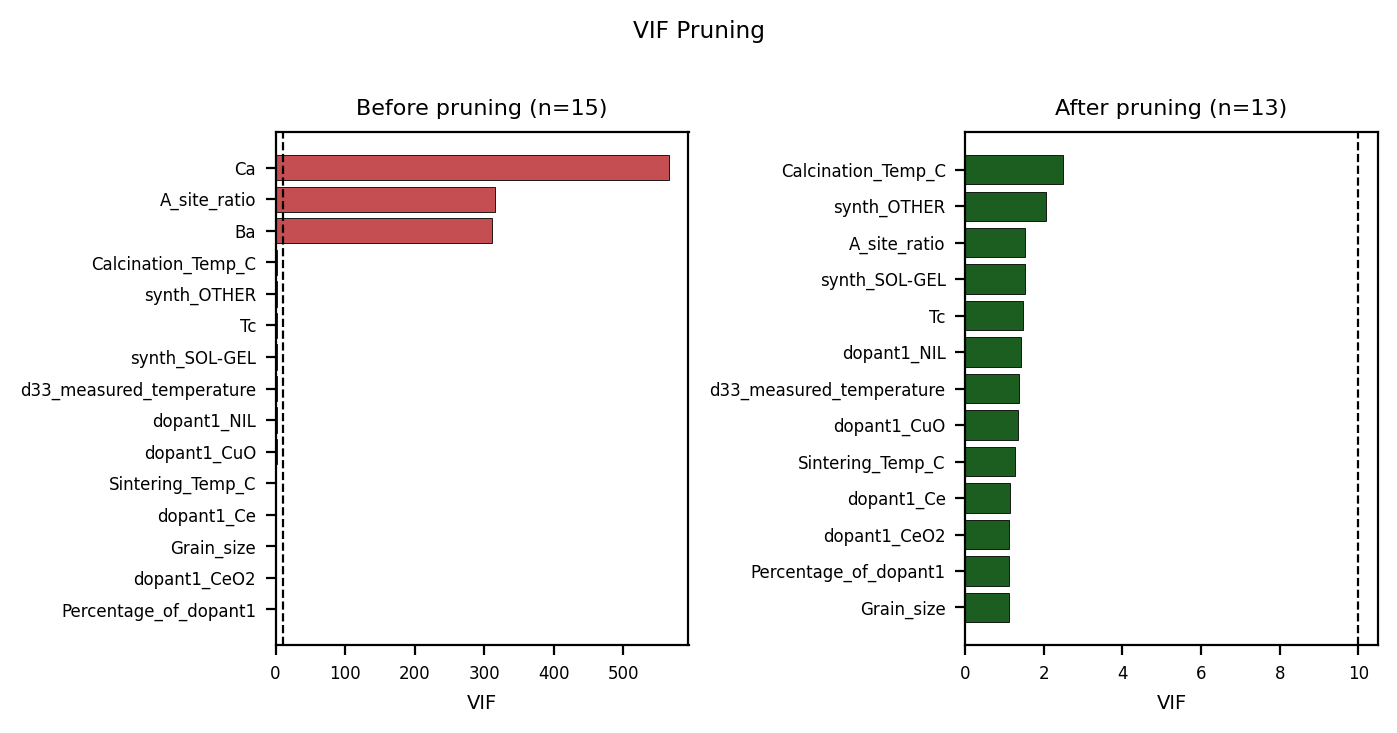

In [20]:
# ============================================================
# Chunk 18: Step 12b — Iterative VIF pruning (threshold=10)
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6
})

from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# Pre-exclude columns that are exact/near-exact linear combinations of other top-16
# members (same rank-deficiency issue found in Pipeline 1-iii):
# - thermal_budget = Sintering_Temp_C - Calcination_Temp_C (exact linear dependency)
# - QNA strongly correlated with EPA
structurally_redundant = ['thermal_budget', 'QNA']
clean_candidates = [f for f in top16 if f not in structurally_redundant]
excluded_present = [f for f in structurally_redundant if f in top16]
print(f"Pre-excluded (structurally redundant, present in this pipeline's top16): {excluded_present}")
print(f"Clean candidate pool ({len(clean_candidates)} features): {clean_candidates}")

X_vif = df_raw[clean_candidates].astype(float).copy()
vif_initial = compute_vif(X_vif)
print("\n" + "="*60)
print(f"INITIAL VIF ({len(clean_candidates)}-feature pool)")
print("="*60)
print(vif_initial.to_string())

dropped = []
threshold = 10
while True:
    vif_table = compute_vif(X_vif)
    max_vif = vif_table['VIF'].max()
    if max_vif <= threshold or X_vif.shape[1] <= 2:
        break
    worst_feat = vif_table.iloc[0]['feature']
    dropped.append((worst_feat, max_vif))
    print(f"Dropping '{worst_feat}' (VIF={max_vif:.2f})")
    X_vif = X_vif.drop(columns=[worst_feat])

print(f"\n{'='*60}")
print(f"FINAL FEATURE SET after VIF pruning ({X_vif.shape[1]} features)")
print(f"{'='*60}")
final_vif = compute_vif(X_vif)
print(final_vif.to_string())
print(f"\nDropped {len(dropped)} additional features: {[d[0] for d in dropped]}")

final_features = X_vif.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].barh(vif_initial['feature'][::-1], vif_initial['VIF'][::-1], color='#C44E52', edgecolor='black', linewidth=0.3)
axes[0].axvline(threshold, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title(f'Before pruning (n={len(vif_initial)})')
axes[0].set_xlabel('VIF')
axes[1].barh(final_vif['feature'][::-1], final_vif['VIF'][::-1], color='#1B5E20', edgecolor='black', linewidth=0.3)
axes[1].axvline(threshold, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title(f'After pruning (n={len(final_vif)})')
axes[1].set_xlabel('VIF')
plt.suptitle('VIF Pruning', y=1.02)
plt.tight_layout()
plt.show()

Final feature set (13): ['Grain_size', 'Tc', 'Sintering_Temp_C', 'Calcination_Temp_C', 'd33_measured_temperature', 'synth_OTHER', 'A_site_ratio', 'dopant1_NIL', 'Percentage_of_dopant1', 'synth_SOL-GEL', 'dopant1_CeO2', 'dopant1_CuO', 'dopant1_Ce']
Total rows: 1126, total journals: 119

Train: 909 rows, 89 journals
Test:  217 rows, 30 journals
Journal overlap between train/test: 0 (must be 0)

GroupKFold(5) ready for cross-validation


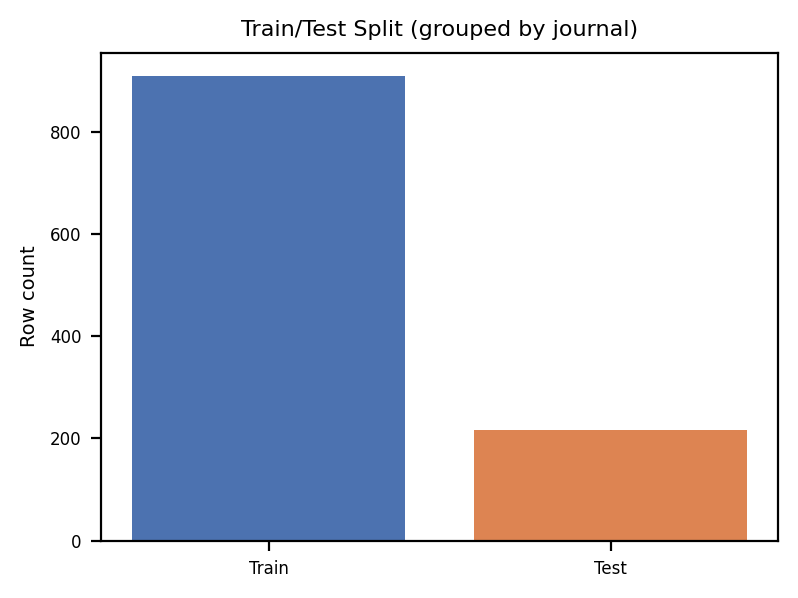

In [21]:
# ============================================================
# Chunk 19: Step 13 — Leakage-safe train/test split
# ============================================================

from sklearn.model_selection import GroupShuffleSplit, GroupKFold

X_final = df_raw[final_features].astype(float)
y_final = df_raw['d33'].astype(float)
groups = df_raw['Journal_number']

print(f"Final feature set ({len(final_features)}): {final_features}")
print(f"Total rows: {len(X_final)}, total journals: {groups.nunique()}")

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_final, y_final, groups))

X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
y_train, y_test = y_final.iloc[train_idx], y_final.iloc[test_idx]

train_journals = set(groups.iloc[train_idx])
test_journals = set(groups.iloc[test_idx])
overlap = train_journals & test_journals

print(f"\nTrain: {len(X_train)} rows, {len(train_journals)} journals")
print(f"Test:  {len(X_test)} rows, {len(test_journals)} journals")
print(f"Journal overlap between train/test: {len(overlap)} (must be 0)")

gkf = GroupKFold(n_splits=5)
print(f"\nGroupKFold(5) ready for cross-validation")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Train','Test'], [len(X_train), len(X_test)], color=['#4C72B0','#DD8452'])
ax.set_ylabel('Row count')
ax.set_title('Train/Test Split (grouped by journal)')
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Chunk 20: Step 14 — 5-fold CV setup (GroupKFold, leakage-safe)
# ============================================================

from sklearn.model_selection import GroupKFold, KFold

train_groups = groups.iloc[train_idx].reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

gkf = GroupKFold(n_splits=5)
leaky_kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("GroupKFold fold sizes and journal-group integrity check:")
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=train_groups)):
    tr_journals = set(train_groups.iloc[tr_idx])
    val_journals = set(train_groups.iloc[val_idx])
    overlap = tr_journals & val_journals
    print(f"  Fold {fold+1}: train={len(tr_idx)}, val={len(val_idx)}, journal overlap={len(overlap)}")

GroupKFold fold sizes and journal-group integrity check:
  Fold 1: train=726, val=183, journal overlap=0
  Fold 2: train=727, val=182, journal overlap=0
  Fold 3: train=727, val=182, journal overlap=0
  Fold 4: train=728, val=181, journal overlap=0
  Fold 5: train=728, val=181, journal overlap=0


In [23]:
# ============================================================
# Chunk 21: Step 15 — 11-model benchmark (GroupKFold CV, leakage-safe)
# ============================================================

!pip install xgboost lightgbm catboost -q

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(random_state=42))]),
    'LASSO': Pipeline([('scaler', StandardScaler()), ('model', Lasso(random_state=42))]),
    'SVR': Pipeline([('scaler', StandardScaler()), ('model', SVR())]),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'MLP': Pipeline([('scaler', StandardScaler()), ('model', MLPRegressor(random_state=42, max_iter=2000))]),
}

results = []
for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=gkf, groups=train_groups,
                              scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
                              n_jobs=-1)
    results.append({
        'Model': name,
        'R2_mean': cv_res['test_r2'].mean(),
        'R2_std': cv_res['test_r2'].std(),
        'RMSE_mean': -cv_res['test_neg_root_mean_squared_error'].mean(),
        'MAE_mean': -cv_res['test_neg_mean_absolute_error'].mean(),
    })

results_df = pd.DataFrame(results).sort_values('R2_mean', ascending=False).reset_index(drop=True)

print("="*70)
print("STEP 15: 11-MODEL BENCHMARK (5-fold GroupKFold CV on training set)")
print("="*70)
print(results_df.to_string(index=False))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00
STEP 15: 11-MODEL BENCHMARK (5-fold GroupKFold CV on training set)
            Model   R2_mean    R2_std  RMSE_mean   MAE_mean
      Extra Trees  0.110903  0.063032 153.743101 120.720015
         CatBoost  0.073071  0.077556 156.626232 125.552591
Gradient Boosting  0.041491  0.125759 159.150243 126.849762
    Random Forest  0.033666  0.206192 158.584527 127.286007
         LightGBM  0.031766  0.134652 159.138584 127.626855
              SVR -0.038595  0.079785 166.008012 133.830746
          XGBoost -0.088176  0.246120 167.708434 136.942529
            LASSO -2.268720  4.636382 236.880309 132.994347
            Ridge -3.285175  6.649837 257.324597 136.945430
Linear Regression -3.286796  6.651724 257.385387 137.025838
              MLP -7.280776 13.773598 335.455959 162.045186


In [24]:
# ============================================================
# Chunk 22: Step 15b — Same 11-model benchmark, standard random KFold
# ============================================================

leaky_results = []
for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=leaky_kf,
                              scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
                              n_jobs=-1)
    leaky_results.append({
        'Model': name,
        'R2_mean': cv_res['test_r2'].mean(),
        'R2_std': cv_res['test_r2'].std(),
        'RMSE_mean': -cv_res['test_neg_root_mean_squared_error'].mean(),
        'MAE_mean': -cv_res['test_neg_mean_absolute_error'].mean(),
    })

leaky_results_df = pd.DataFrame(leaky_results).sort_values('R2_mean', ascending=False).reset_index(drop=True)

print("="*70)
print("STEP 15: 11-MODEL BENCHMARK (5-fold LEAKY KFold — for comparison only)")
print("="*70)
print(leaky_results_df.to_string(index=False))

comparison = results_df.set_index('Model')[['R2_mean']].rename(columns={'R2_mean': 'honest_R2'})
comparison['leaky_R2'] = leaky_results_df.set_index('Model')['R2_mean']
comparison['inflation_gap'] = comparison['leaky_R2'] - comparison['honest_R2']
comparison = comparison.sort_values('honest_R2', ascending=False)
print("\n" + "="*70)
print("HONEST vs LEAKY — INFLATION GAP")
print("="*70)
print(comparison.to_string())

STEP 15: 11-MODEL BENCHMARK (5-fold LEAKY KFold — for comparison only)
            Model  R2_mean   R2_std  RMSE_mean   MAE_mean
         CatBoost 0.690773 0.043066  92.231971  62.783865
      Extra Trees 0.682645 0.057204  93.231928  58.436885
    Random Forest 0.672990 0.041123  94.865802  63.466821
          XGBoost 0.656237 0.052262  97.200875  62.846540
         LightGBM 0.638968 0.037099  99.789254  69.439967
Gradient Boosting 0.617853 0.024436 102.926557  77.597438
              MLP 0.489837 0.033303 119.077550  89.140860
            LASSO 0.292117 0.031782 140.273399 108.160756
            Ridge 0.289382 0.037224 140.524520 108.358390
Linear Regression 0.289269 0.037362 140.534937 108.360188
              SVR 0.084321 0.015887 159.600833 126.888127

HONEST vs LEAKY — INFLATION GAP
                   honest_R2  leaky_R2  inflation_gap
Model                                                
Extra Trees         0.110903  0.682645       0.571742
CatBoost            0.073071  0.690773

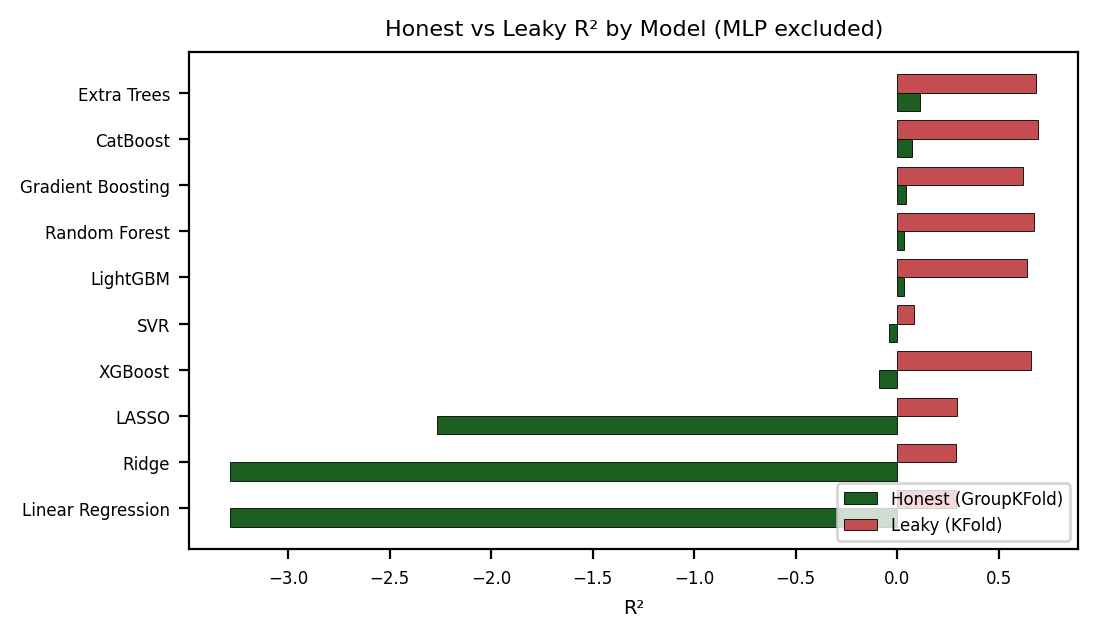

In [25]:
# ============================================================
# Chunk 23: Leakage inflation, visualized (MLP excluded)
# ============================================================

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6
})

comp_sorted = comparison.drop(index='MLP').sort_values('honest_R2', ascending=True)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
y_pos = np.arange(len(comp_sorted))
ax.barh(y_pos - 0.2, comp_sorted['honest_R2'], height=0.4, color='#1B5E20', edgecolor='black', linewidth=0.3, label='Honest (GroupKFold)')
ax.barh(y_pos + 0.2, comp_sorted['leaky_R2'], height=0.4, color='#C44E52', edgecolor='black', linewidth=0.3, label='Leaky (KFold)')
ax.set_yticks(y_pos)
ax.set_yticklabels(comp_sorted.index)
ax.set_xlabel('R²')
ax.set_title('Honest vs Leaky R² by Model (MLP excluded)')
ax.legend(fontsize=6, loc='lower right')
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# Chunk 24: Step 16 — Hyperparameter tuning (top candidate models)
# Tunes the top-performing models from the honest benchmark (Chunk 21)
# using RandomizedSearchCV with the SAME leakage-safe GroupKFold CV.
# Generic — works unchanged in 2-i, 2-ii, 2-iii (reads each tab's own results_df).
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

TOP_N_TO_TUNE = 4
top_models_to_tune = results_df.head(TOP_N_TO_TUNE)['Model'].tolist()
print(f"Tuning top {TOP_N_TO_TUNE} models (by honest R2 from Chunk 21): {top_models_to_tune}")

param_grids = {
    'Linear Regression': None,  # no hyperparameters to tune
    'Ridge': {'model__alpha': [0.1, 1, 3, 10, 30, 100, 300, 1000]},
    'LASSO': {'model__alpha': [0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1, 3]},
    'SVR': {'model__C': [0.1, 1, 10, 100], 'model__gamma': ['scale', 'auto'], 'model__epsilon': [0.01, 0.1, 0.5]},
    'Random Forest': {'n_estimators': [200, 300, 500], 'max_depth': [None, 5, 10, 15],
                       'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 0.5, 1.0]},
    'Extra Trees': {'n_estimators': [200, 300, 500], 'max_depth': [None, 5, 10, 15],
                     'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 0.5, 1.0]},
    'Gradient Boosting': {'n_estimators': [100, 200, 300], 'max_depth': [2, 3, 4],
                           'learning_rate': [0.01, 0.03, 0.1], 'subsample': [0.7, 0.85, 1.0]},
    'XGBoost': {'n_estimators': [100, 200, 300], 'max_depth': [2, 3, 4, 5],
                'learning_rate': [0.01, 0.03, 0.1], 'subsample': [0.7, 0.85, 1.0],
                'colsample_bytree': [0.7, 0.85, 1.0]},
    'LightGBM': {'n_estimators': [100, 200, 300], 'max_depth': [-1, 3, 5, 7],
                 'learning_rate': [0.01, 0.03, 0.1], 'num_leaves': [15, 31, 63],
                 'subsample': [0.7, 0.85, 1.0]},
    'CatBoost': {'iterations': [200, 400, 600], 'depth': [3, 4, 5, 6],
                 'learning_rate': [0.01, 0.03, 0.1, 0.3], 'l2_leaf_reg': [1, 3, 5, 10]},
    'MLP': {'model__hidden_layer_sizes': [(50,), (100,), (50,50), (100,50)],
            'model__alpha': [0.0001, 0.001, 0.01], 'model__learning_rate_init': [0.001, 0.01]},
}

tuned_models = {}
tuning_results = []

for name in top_models_to_tune:
    grid = param_grids.get(name)
    base_model = models[name]

    if grid is None:
        tuned_models[name] = base_model
        row = results_df[results_df['Model'] == name].iloc[0]
        tuning_results.append({'Model': name, 'Best_R2_CV': row['R2_mean'], 'Best_Params': 'N/A (no tunable params)'})
        print(f"\n{name}: no tunable hyperparameters, keeping baseline (R2={row['R2_mean']:.4f})")
        continue

    n_iter = min(30, int(np.prod([len(v) for v in grid.values()])))
    search = RandomizedSearchCV(
        base_model, grid, n_iter=n_iter, cv=gkf, scoring='r2',
        n_jobs=-1, random_state=42, refit=True
    )
    search.fit(X_train, y_train, groups=train_groups)

    tuned_models[name] = search.best_estimator_
    tuning_results.append({'Model': name, 'Best_R2_CV': search.best_score_, 'Best_Params': str(search.best_params_)})
    print(f"\n{name}: best CV R2 = {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")

tuning_results_df = pd.DataFrame(tuning_results)
print("\n" + "="*70)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*70)
print(tuning_results_df.to_string(index=False))

Tuning top 4 models (by honest R2 from Chunk 21): ['Extra Trees', 'CatBoost', 'Gradient Boosting', 'Random Forest']

Extra Trees: best CV R2 = 0.1452
  Best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10}

CatBoost: best CV R2 = 0.0916
  Best params: {'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations': 200, 'depth': 6}

Gradient Boosting: best CV R2 = 0.1166
  Best params: {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01}

Random Forest: best CV R2 = 0.1292
  Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}

HYPERPARAMETER TUNING SUMMARY
            Model  Best_R2_CV                                                                           Best_Params
      Extra Trees    0.145153    {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10}
         CatBoost    0.091603              {'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations':

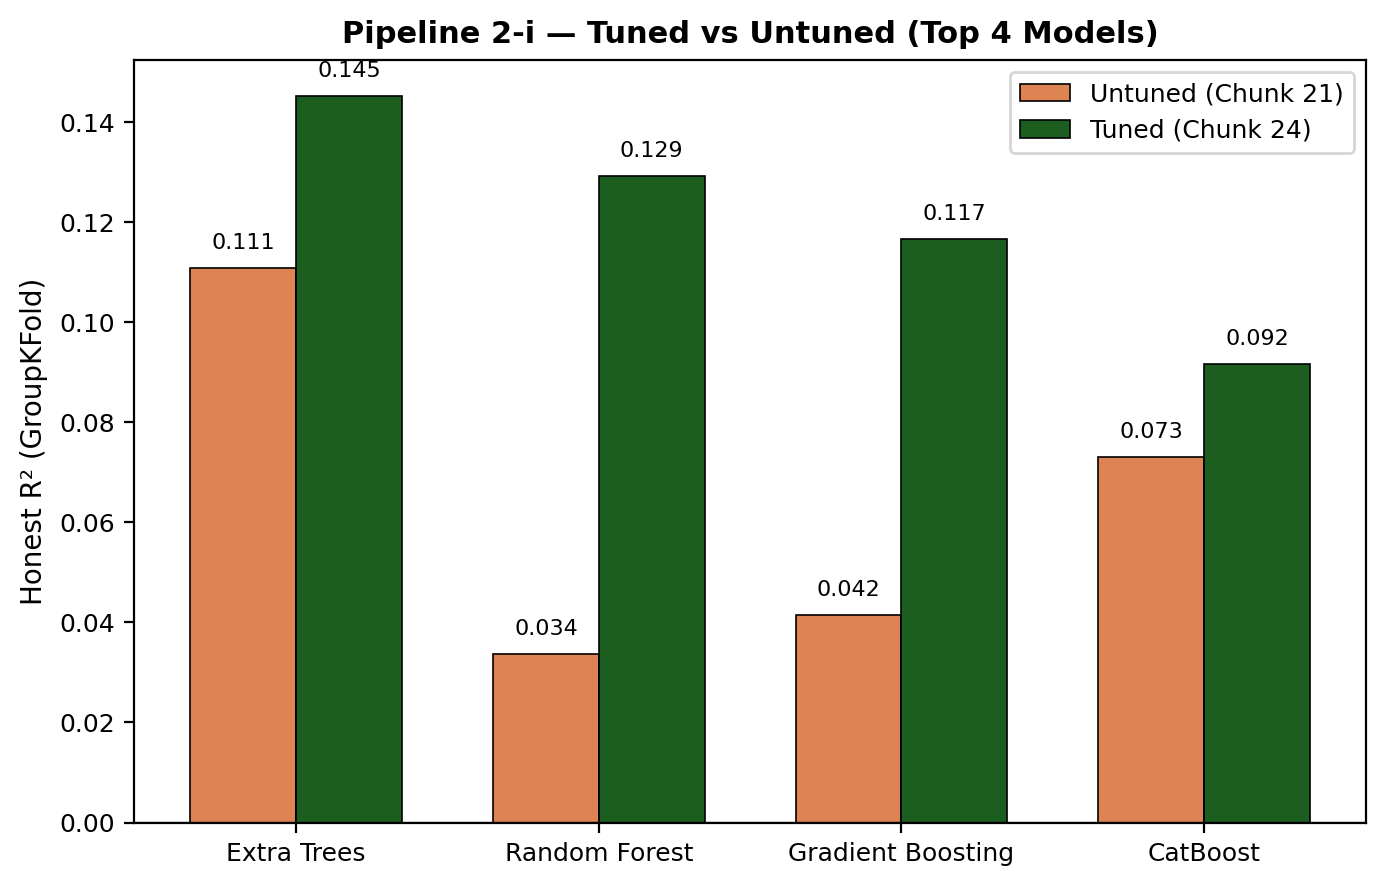

Champion model for stability check: Extra Trees
  seed  0: mean honest R2 = 0.0974
  seed  1: mean honest R2 = 0.1430
  seed  2: mean honest R2 = -0.0105
  seed  3: mean honest R2 = 0.1158
  seed  4: mean honest R2 = 0.2383
  seed  5: mean honest R2 = 0.0307
  seed  6: mean honest R2 = 0.1354
  seed  7: mean honest R2 = 0.2369
  seed  8: mean honest R2 = 0.0494
  seed  9: mean honest R2 = 0.0042
  seed 10: mean honest R2 = 0.1492
  seed 11: mean honest R2 = 0.2062
  seed 12: mean honest R2 = 0.0415
  seed 13: mean honest R2 = 0.0636
  seed 14: mean honest R2 = 0.1025

Across 15 random train/test splits:
  Mean R2 = 0.1069
  Std  R2 = 0.0765
  Min/Max = -0.0105 / 0.2383


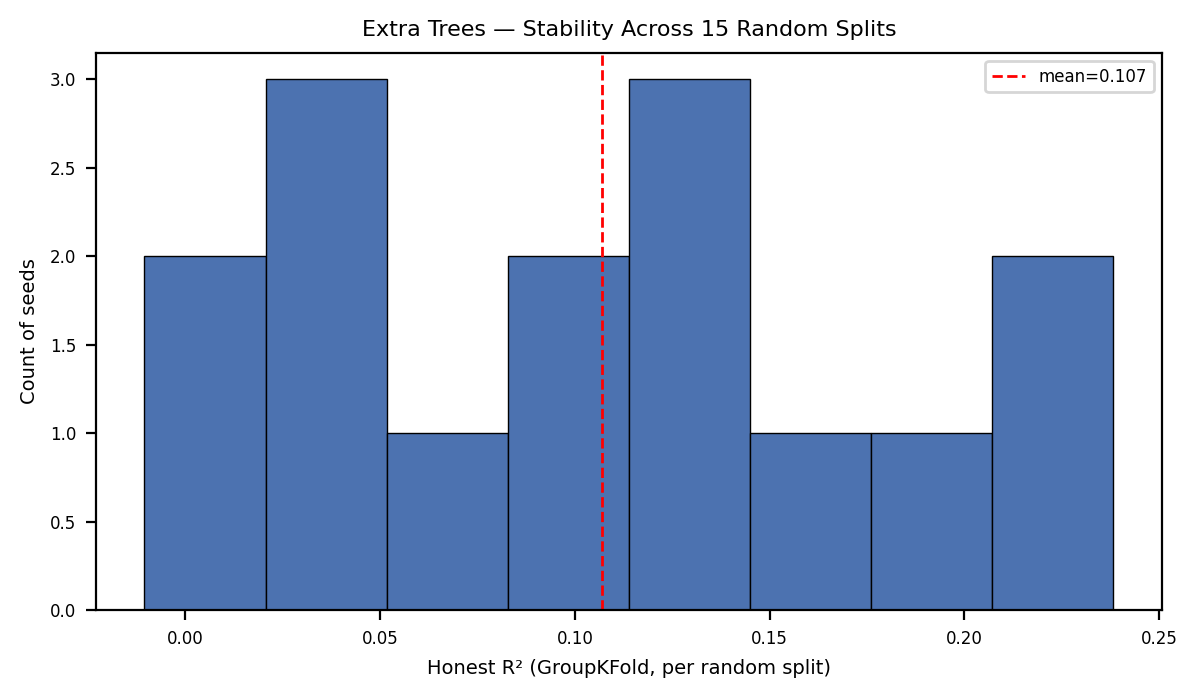

In [27]:
# ============================================================
# Chunk 25: Step 17 — Multi-seed stability check
# Re-evaluates the tuned champion across 15 different random train/test
# splits (GroupShuffleSplit seeds) to check whether the reported R2 is a
# stable estimate or an artifact of which journals landed in train vs test.
# Generic — works unchanged in any tab once Chunk 24 has run.
# ============================================================

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
import numpy as np

CHAMPION_NAME = tuning_results_df.sort_values('Best_R2_CV', ascending=False).iloc[0]['Model']
champion_model = tuned_models[CHAMPION_NAME]
print(f"Champion model for stability check: {CHAMPION_NAME}")

N_SEEDS = 15
seed_r2_scores = []

for seed in range(N_SEEDS):
    gss_seed = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    tr_idx, te_idx = next(gss_seed.split(X_final, y_final, groups))
    X_tr = X_final.iloc[tr_idx].reset_index(drop=True)
    y_tr = y_final.iloc[tr_idx].reset_index(drop=True)
    tr_groups = groups.iloc[tr_idx].reset_index(drop=True)

    gkf_seed = GroupKFold(n_splits=5)
    scores = cross_val_score(champion_model, X_tr, y_tr, cv=gkf_seed, groups=tr_groups, scoring='r2', n_jobs=-1)
    seed_r2_scores.append(scores.mean())
    print(f"  seed {seed:2d}: mean honest R2 = {scores.mean():.4f}")

seed_r2_scores = np.array(seed_r2_scores)
print(f"\nAcross {N_SEEDS} random train/test splits:")
print(f"  Mean R2 = {seed_r2_scores.mean():.4f}")
print(f"  Std  R2 = {seed_r2_scores.std():.4f}")
print(f"  Min/Max = {seed_r2_scores.min():.4f} / {seed_r2_scores.max():.4f}")

fig, ax = plt.subplots(figsize=(6,3.5))
ax.hist(seed_r2_scores, bins=8, color='#4C72B0', edgecolor='black', linewidth=0.5)
ax.axvline(seed_r2_scores.mean(), color='red', linestyle='--', linewidth=1, label=f'mean={seed_r2_scores.mean():.3f}')
ax.set_xlabel('Honest R² (GroupKFold, per random split)')
ax.set_ylabel('Count of seeds')
ax.set_title(f'{CHAMPION_NAME} — Stability Across {N_SEEDS} Random Splits')
ax.legend()
plt.tight_layout()
plt.show()

Final champion model: Extra Trees
Training on 909 rows (89 journals)
Evaluating on 217 held-out rows (30 journals, never seen)

FINAL HELD-OUT TEST SET PERFORMANCE — Extra Trees
R²   = 0.1582
RMSE = 146.50
MAE  = 121.31


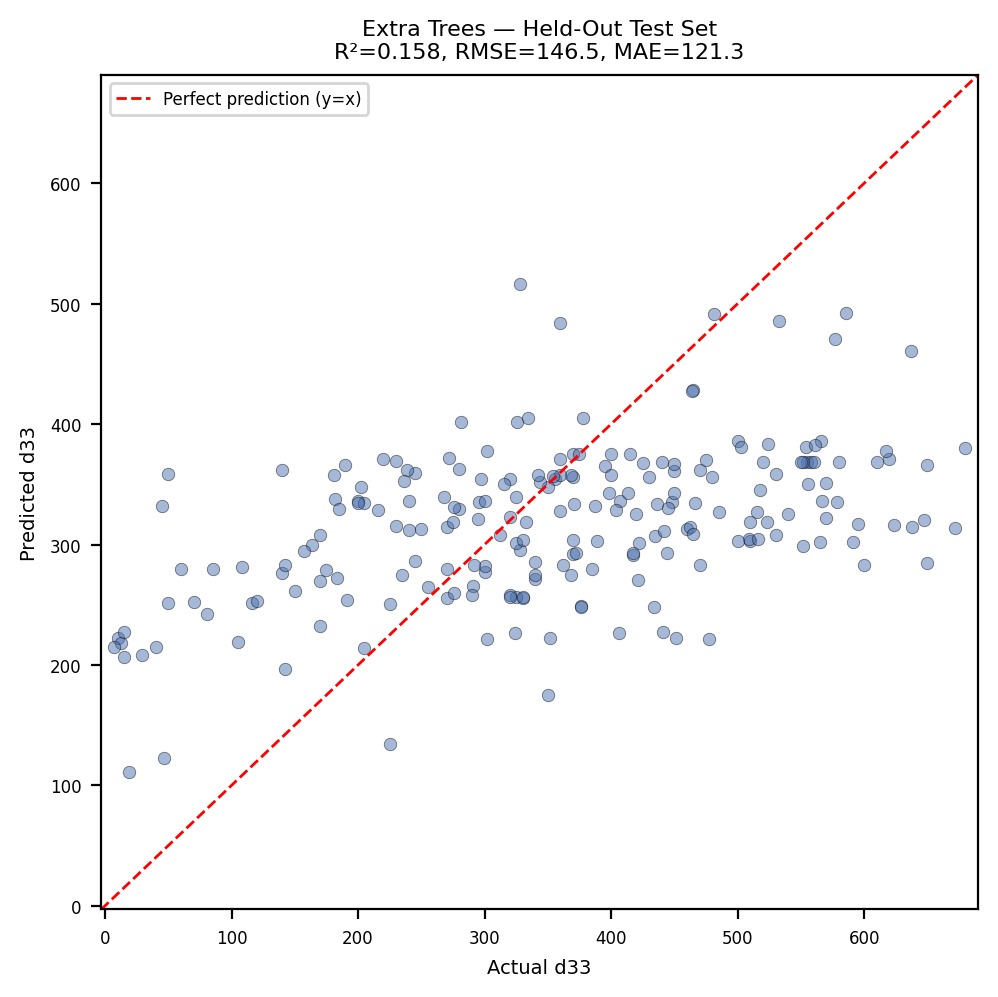

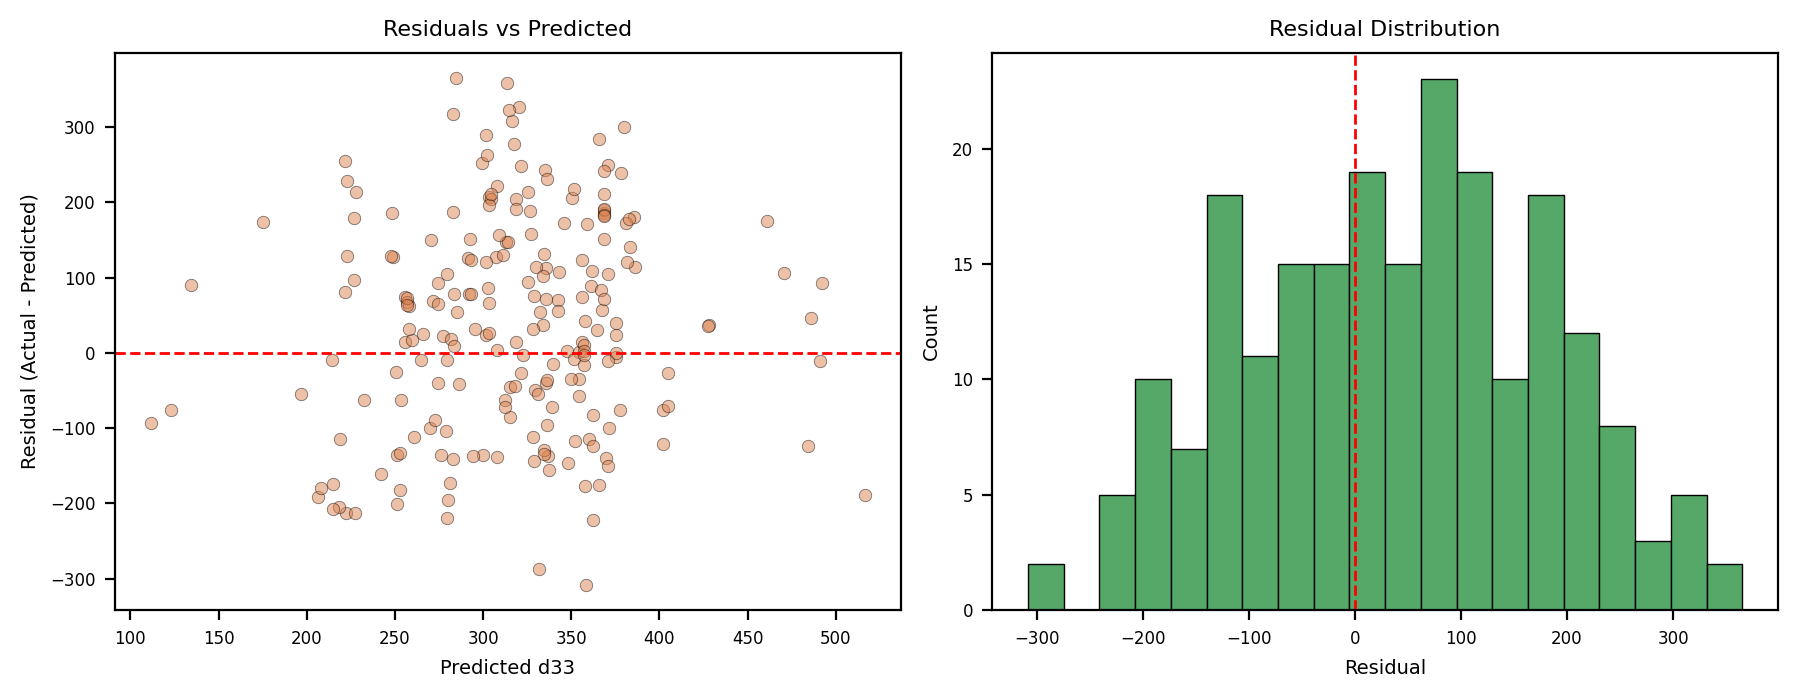

In [28]:
# ============================================================
# Chunk 26: Step 18 — Final train/test evaluation
# Fits the tuned champion on the FULL training set and evaluates ONCE
# on the held-out test set (journals never seen during tuning or CV).
# Generic — works unchanged in any tab once Chunk 24 has run.
# ============================================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

CHAMPION_NAME = tuning_results_df.sort_values('Best_R2_CV', ascending=False).iloc[0]['Model']
final_model = tuned_models[CHAMPION_NAME]

print(f"Final champion model: {CHAMPION_NAME}")
print(f"Training on {len(X_train)} rows ({train_groups.nunique()} journals)")
print(f"Evaluating on {len(X_test)} held-out rows ({groups.iloc[test_idx].nunique()} journals, never seen)")

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print(f"\n{'='*60}")
print(f"FINAL HELD-OUT TEST SET PERFORMANCE — {CHAMPION_NAME}")
print(f"{'='*60}")
print(f"R²   = {test_r2:.4f}")
print(f"RMSE = {test_rmse:.2f}")
print(f"MAE  = {test_mae:.2f}")

# --- Predicted vs actual ---
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_test, y_pred, alpha=0.5, s=20, color='#4C72B0', edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred.min())-10, max(y_test.max(), y_pred.max())+10]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction (y=x)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual d33')
ax.set_ylabel('Predicted d33')
ax.set_title(f'{CHAMPION_NAME} — Held-Out Test Set\nR²={test_r2:.3f}, RMSE={test_rmse:.1f}, MAE={test_mae:.1f}')
ax.legend()
plt.tight_layout()
plt.show()

# --- Residual diagnostics ---
residuals = y_test.values - y_pred
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].scatter(y_pred, residuals, alpha=0.5, s=20, color='#DD8452', edgecolor='k', linewidth=0.3)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted d33')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=20, color='#55A868', edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

Computing SHAP values for final champion: Extra Trees

FEATURE IMPORTANCE (mean |SHAP|) — Extra Trees
Tc                          19.778944
Grain_size                  18.094027
Sintering_Temp_C            17.051576
Calcination_Temp_C          16.229533
dopant1_NIL                 14.763865
d33_measured_temperature    11.512720
A_site_ratio                10.916028
dopant1_Ce                   6.827731
dopant1_CeO2                 6.676576
synth_OTHER                  5.465966
synth_SOL-GEL                3.509769
dopant1_CuO                  3.101386
Percentage_of_dopant1        2.813355


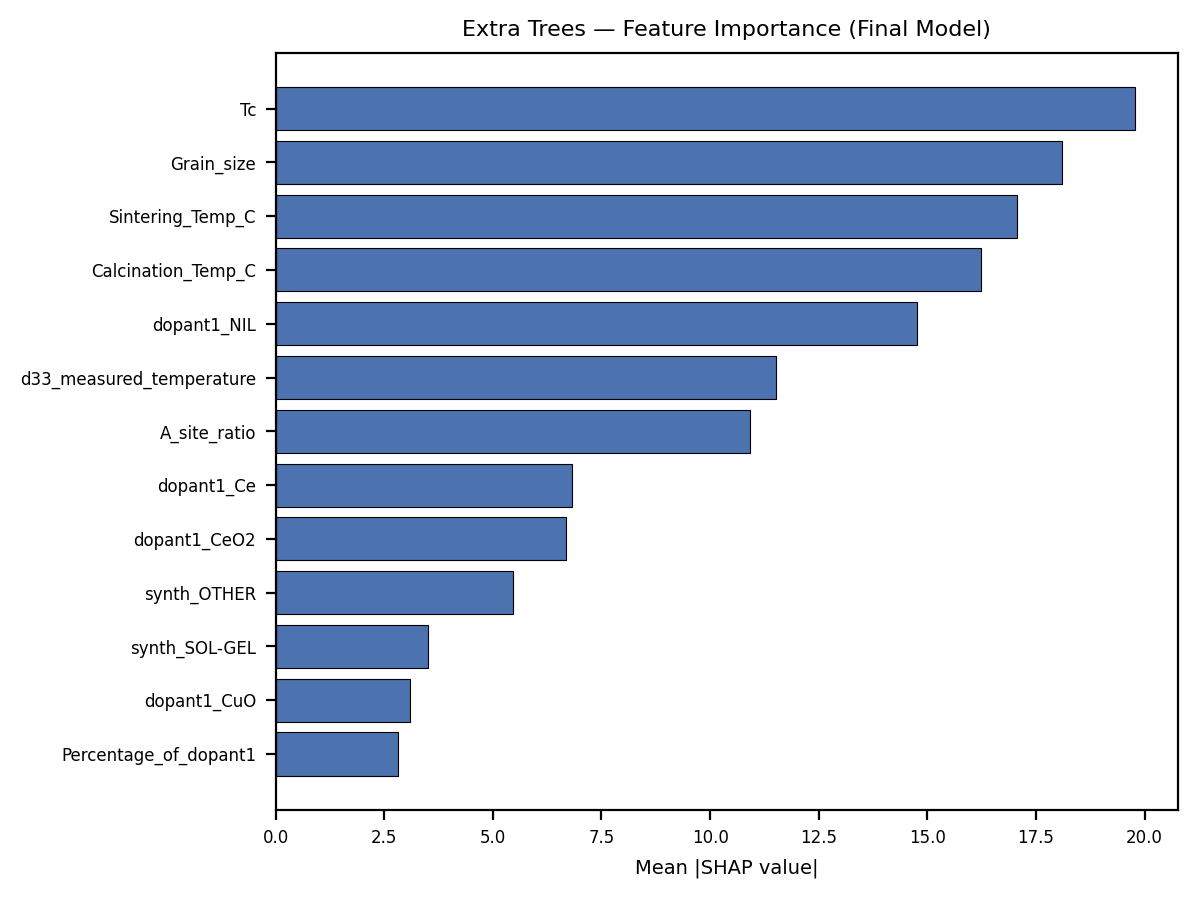

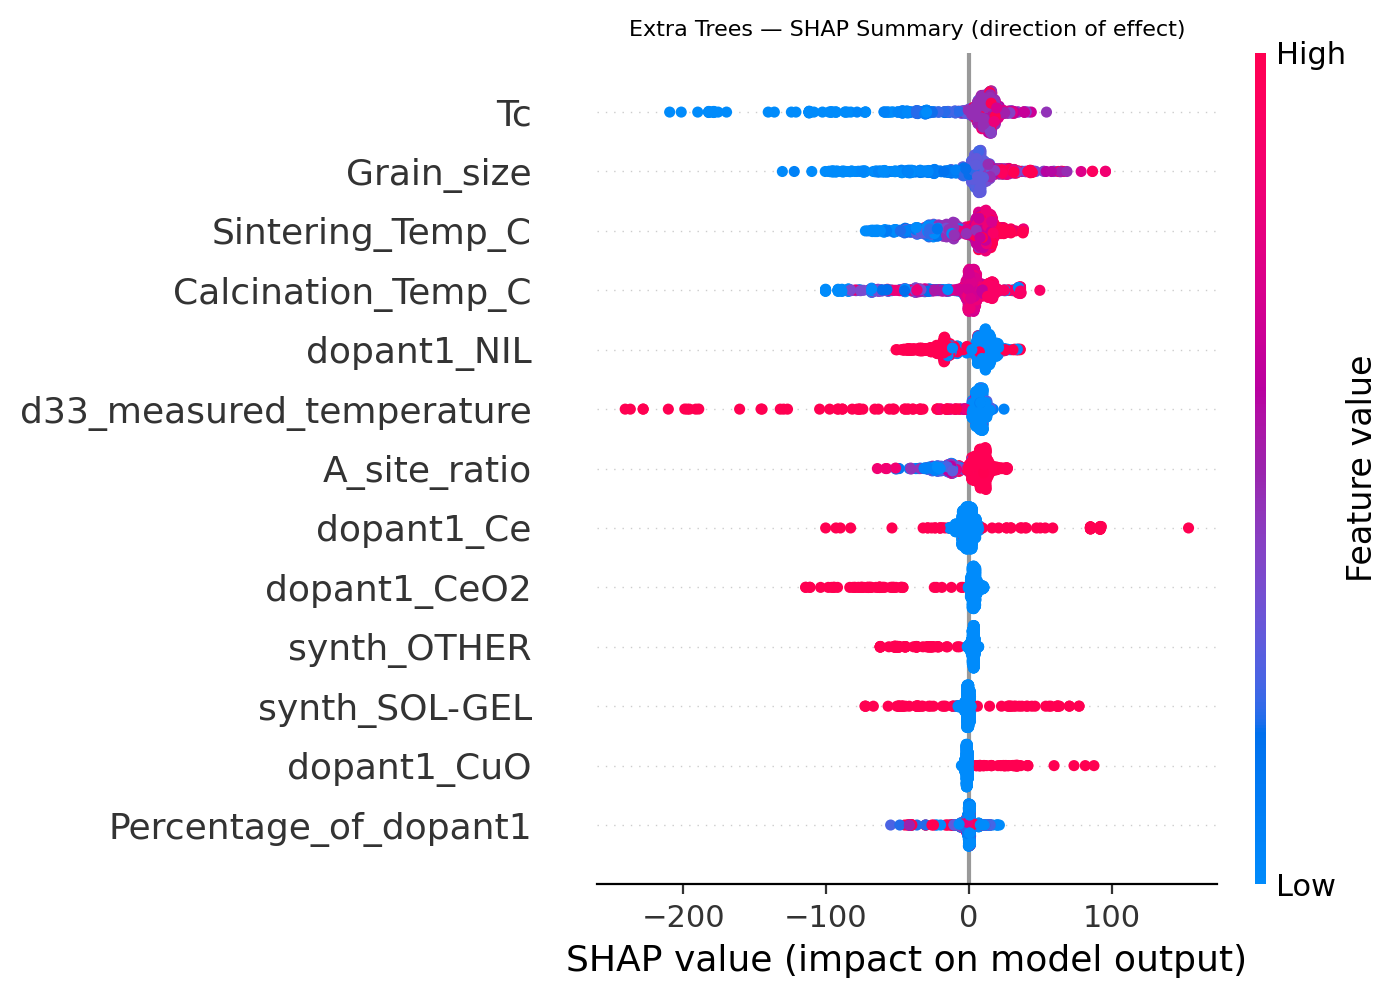

In [29]:
# ============================================================
# Chunk 27: Step 19 — SHAP analysis on the final trained champion
# Explains what's driving predictions from the final fitted champion,
# computed across the full leakage-safe feature set (train+test).
# Generic — works for tree-ensemble or linear champions.
# ============================================================

import shap

print(f"Computing SHAP values for final champion: {CHAMPION_NAME}")

if hasattr(final_model, 'estimators_'):  # tree-ensemble models (Extra Trees, RF, GB, etc.)
    explainer_final = shap.TreeExplainer(final_model)
    shap_values_final = explainer_final.shap_values(X_final)
else:  # linear/other models (wrapped in a scaler Pipeline)
    background = shap.sample(X_train, min(100, len(X_train)), random_state=42)
    explainer_final = shap.Explainer(final_model.predict, background)
    shap_values_final = explainer_final(X_final).values

mean_abs_shap = pd.Series(np.abs(shap_values_final).mean(axis=0), index=final_features).sort_values(ascending=False)

print("\n" + "="*60)
print(f"FEATURE IMPORTANCE (mean |SHAP|) — {CHAMPION_NAME}")
print("="*60)
print(mean_abs_shap.to_string())

# --- Bar chart: overall importance ---
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(mean_abs_shap.index[::-1], mean_abs_shap.values[::-1], color='#4C72B0', edgecolor='black', linewidth=0.4)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'{CHAMPION_NAME} — Feature Importance (Final Model)')
plt.tight_layout()
plt.show()

# --- Beeswarm: importance + direction of effect ---
plt.figure(figsize=(7, 5))
shap.summary_plot(shap_values_final, X_final, feature_names=final_features, show=False, plot_size=None)
plt.title(f'{CHAMPION_NAME} — SHAP Summary (direction of effect)')
plt.tight_layout()
plt.show()

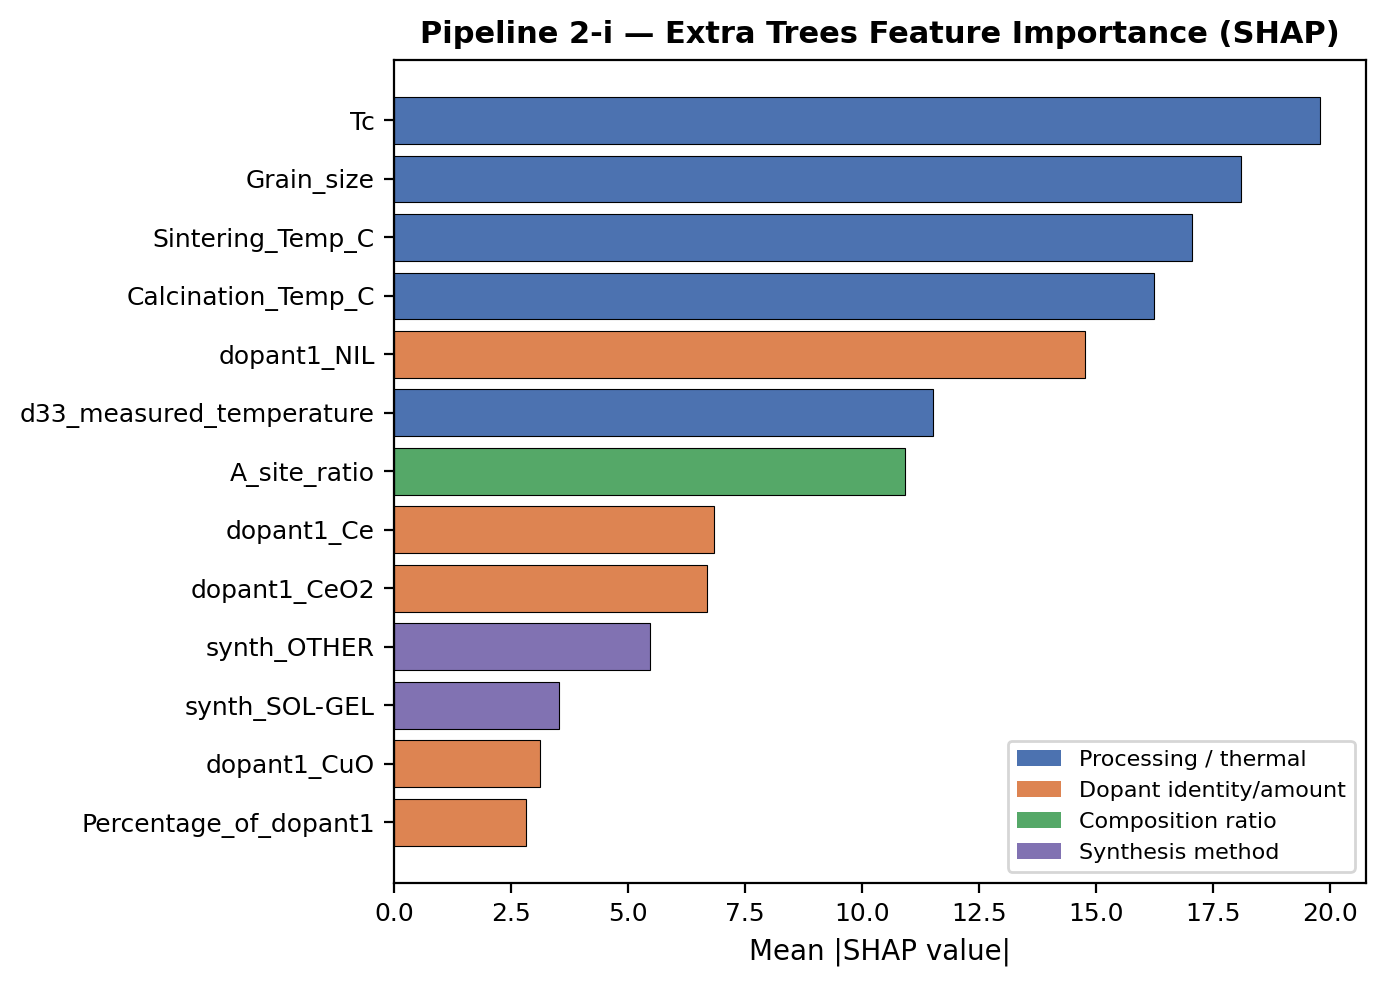

Partial dependence plots for: ['Tc', 'Grain_size', 'Sintering_Temp_C', 'Calcination_Temp_C', 'A_site_ratio']


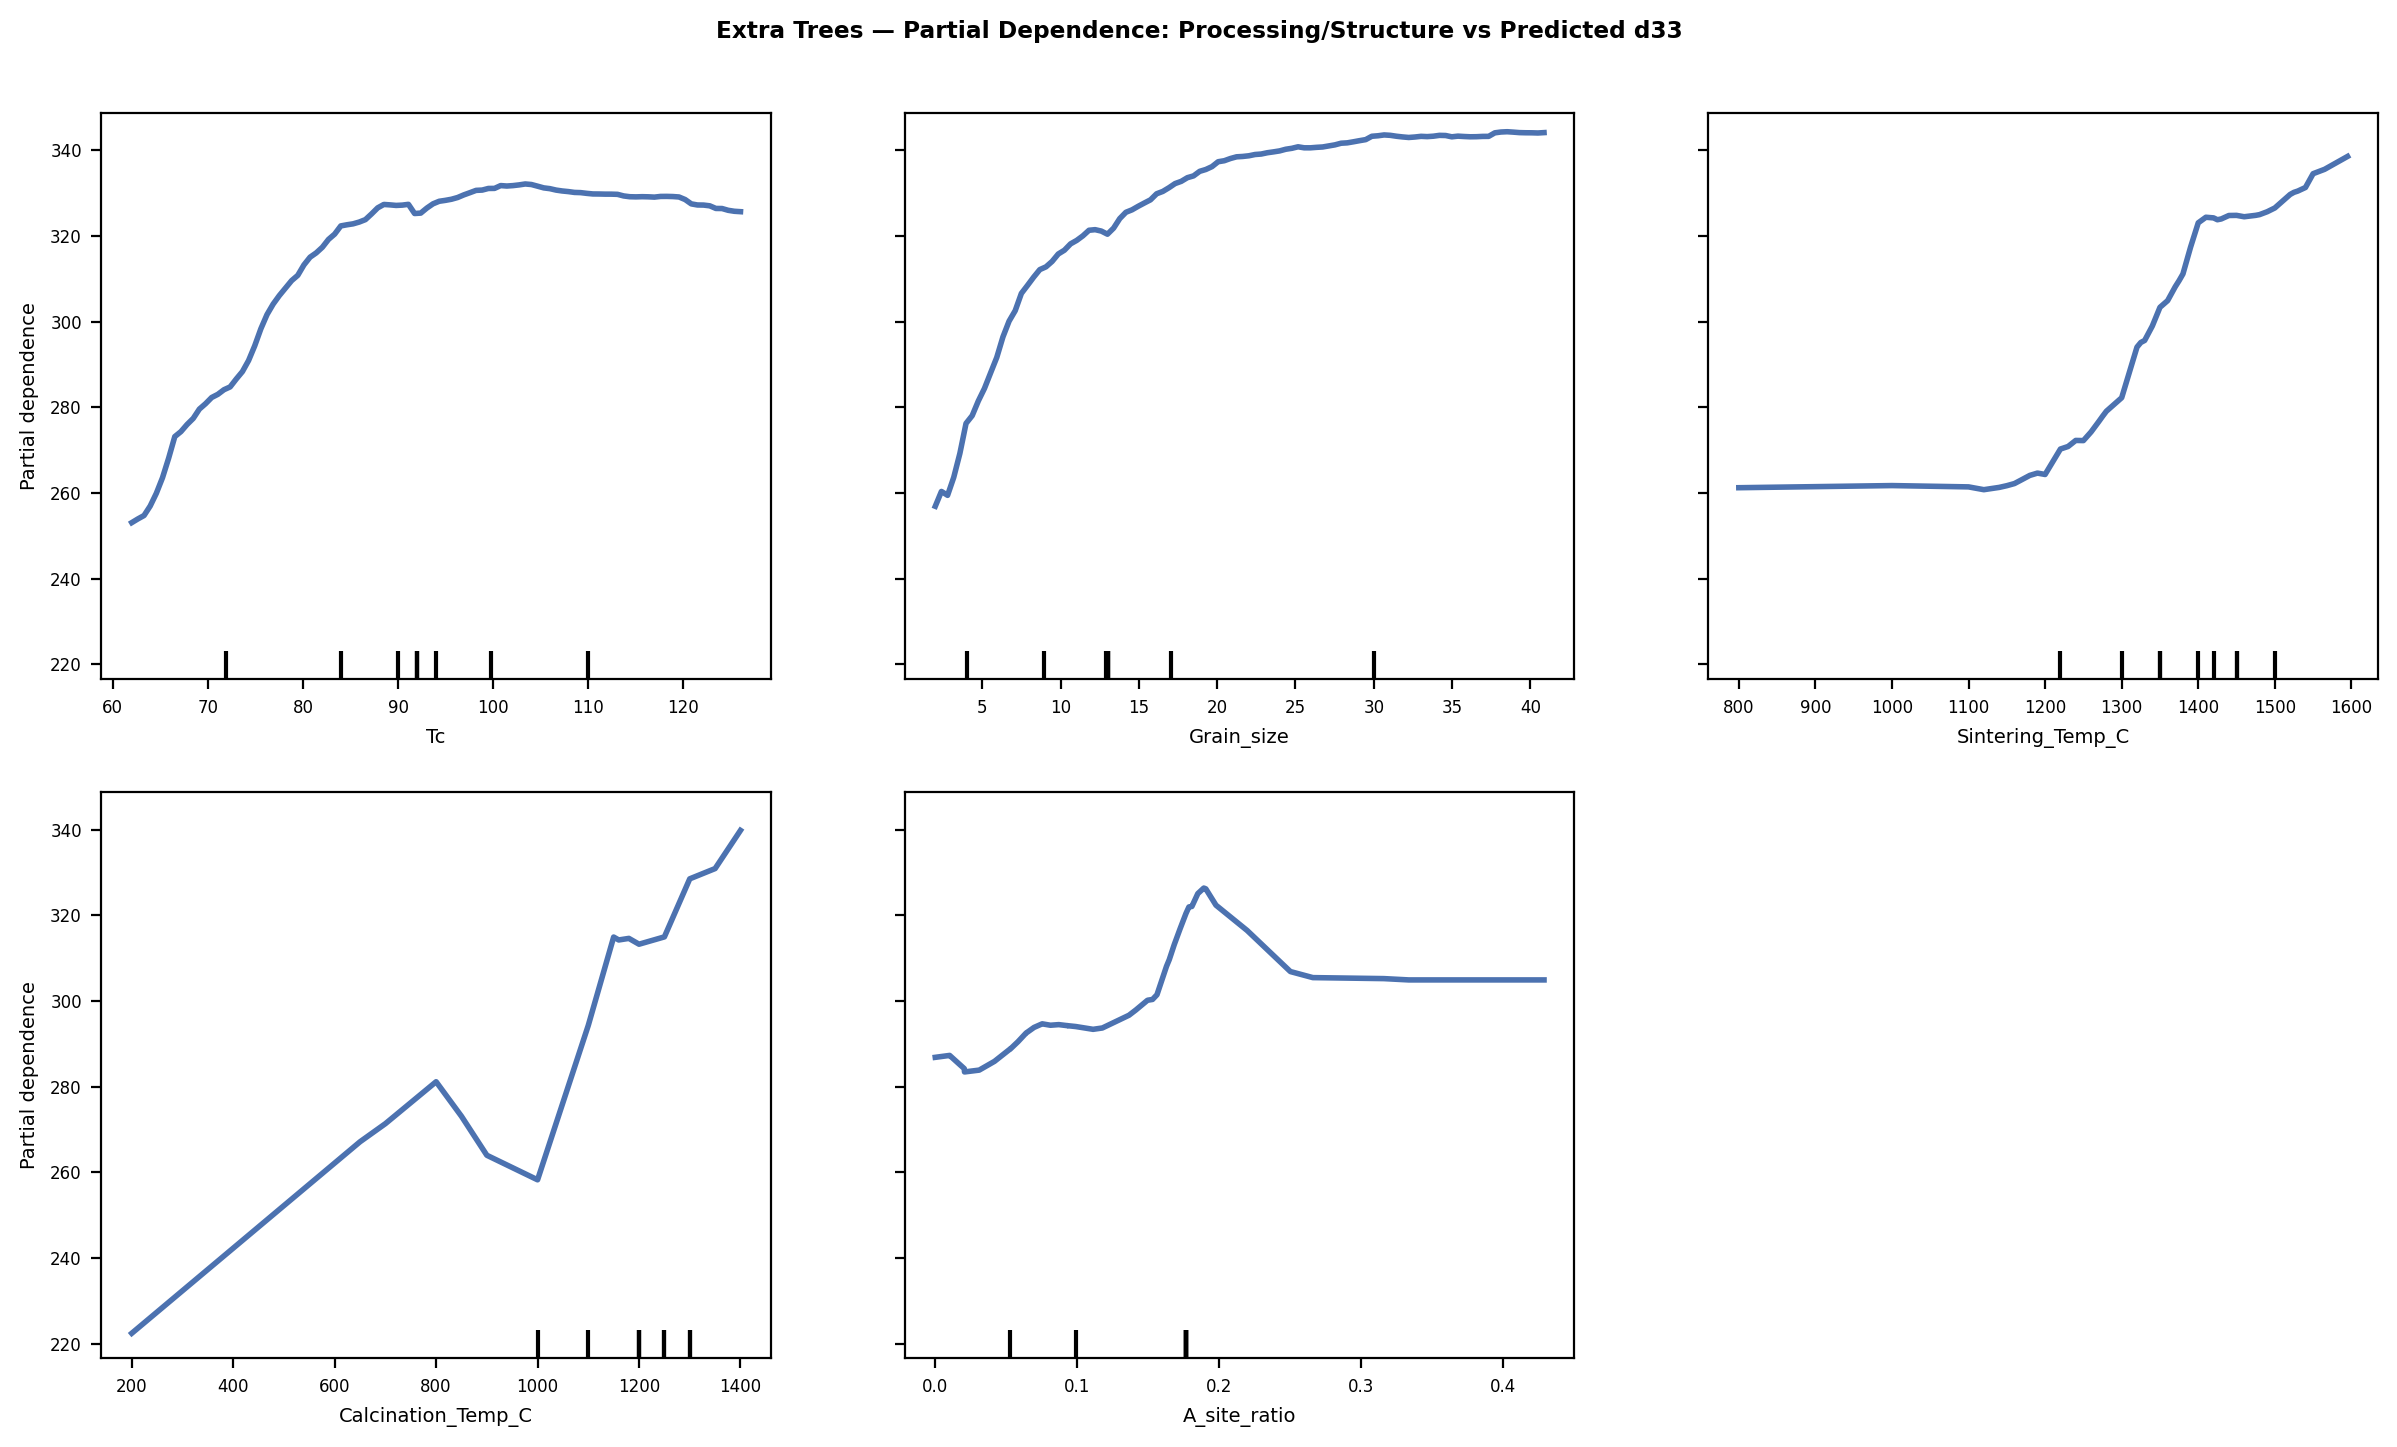

<Figure size 1000x800 with 0 Axes>

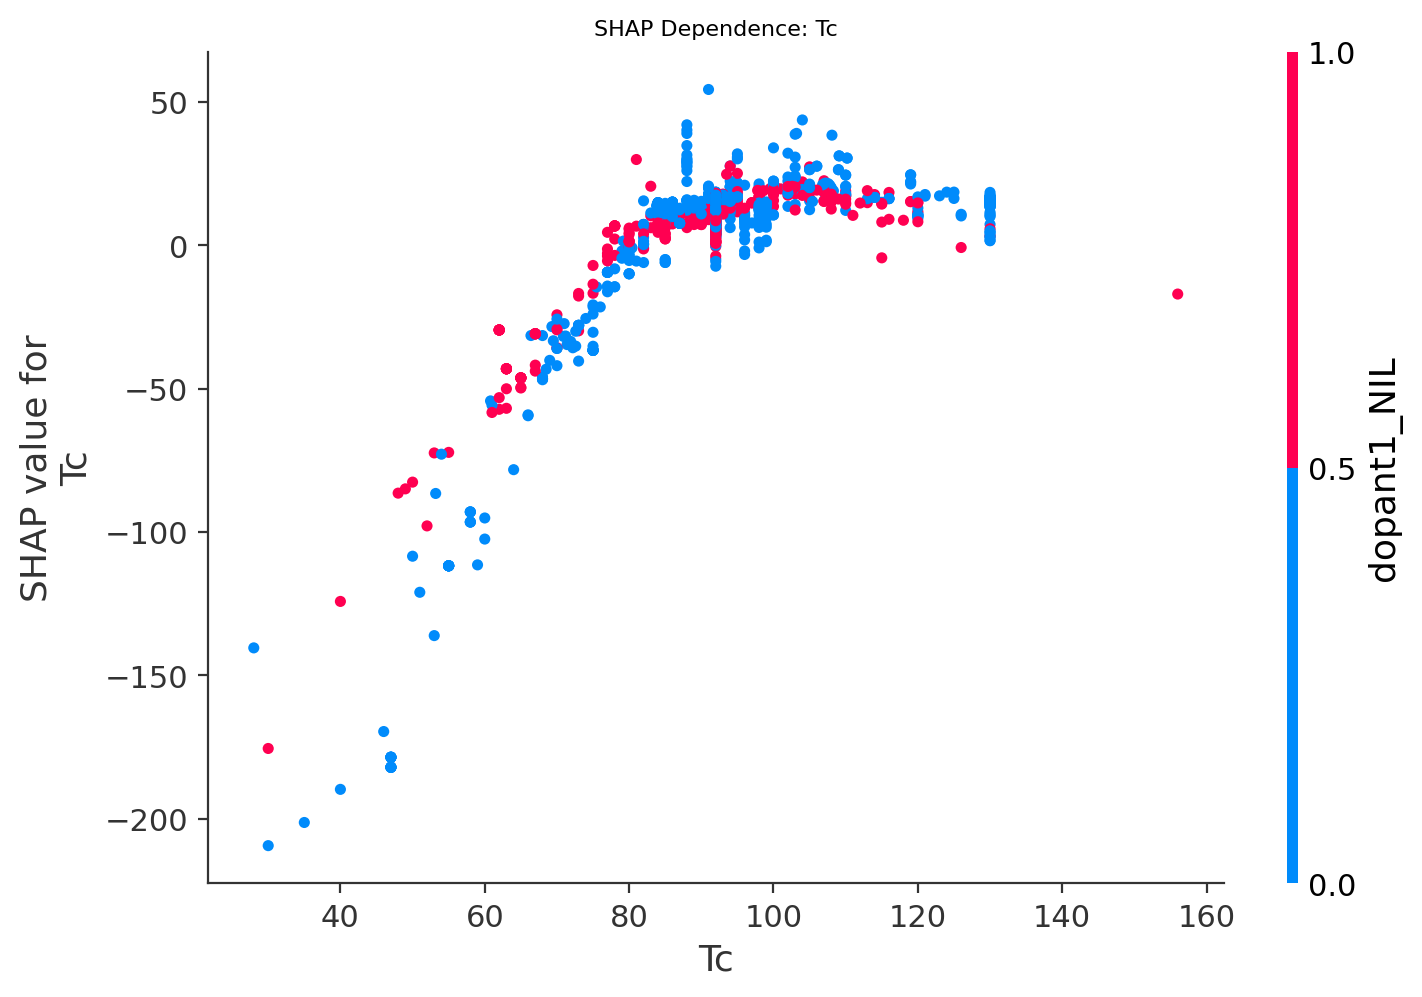

<Figure size 1000x800 with 0 Axes>

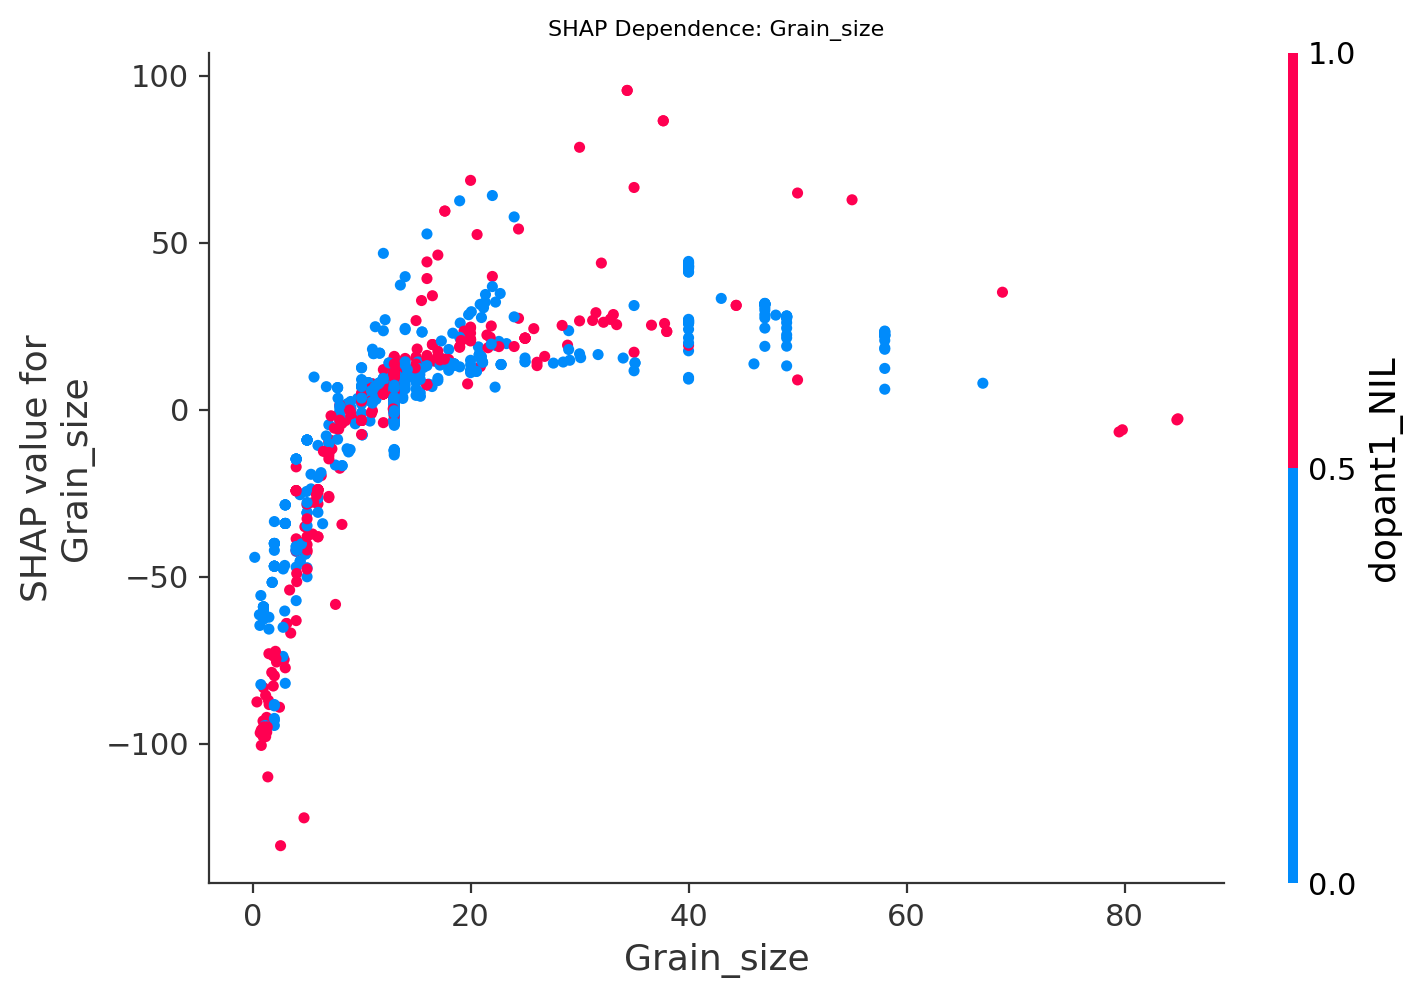

<Figure size 1000x800 with 0 Axes>

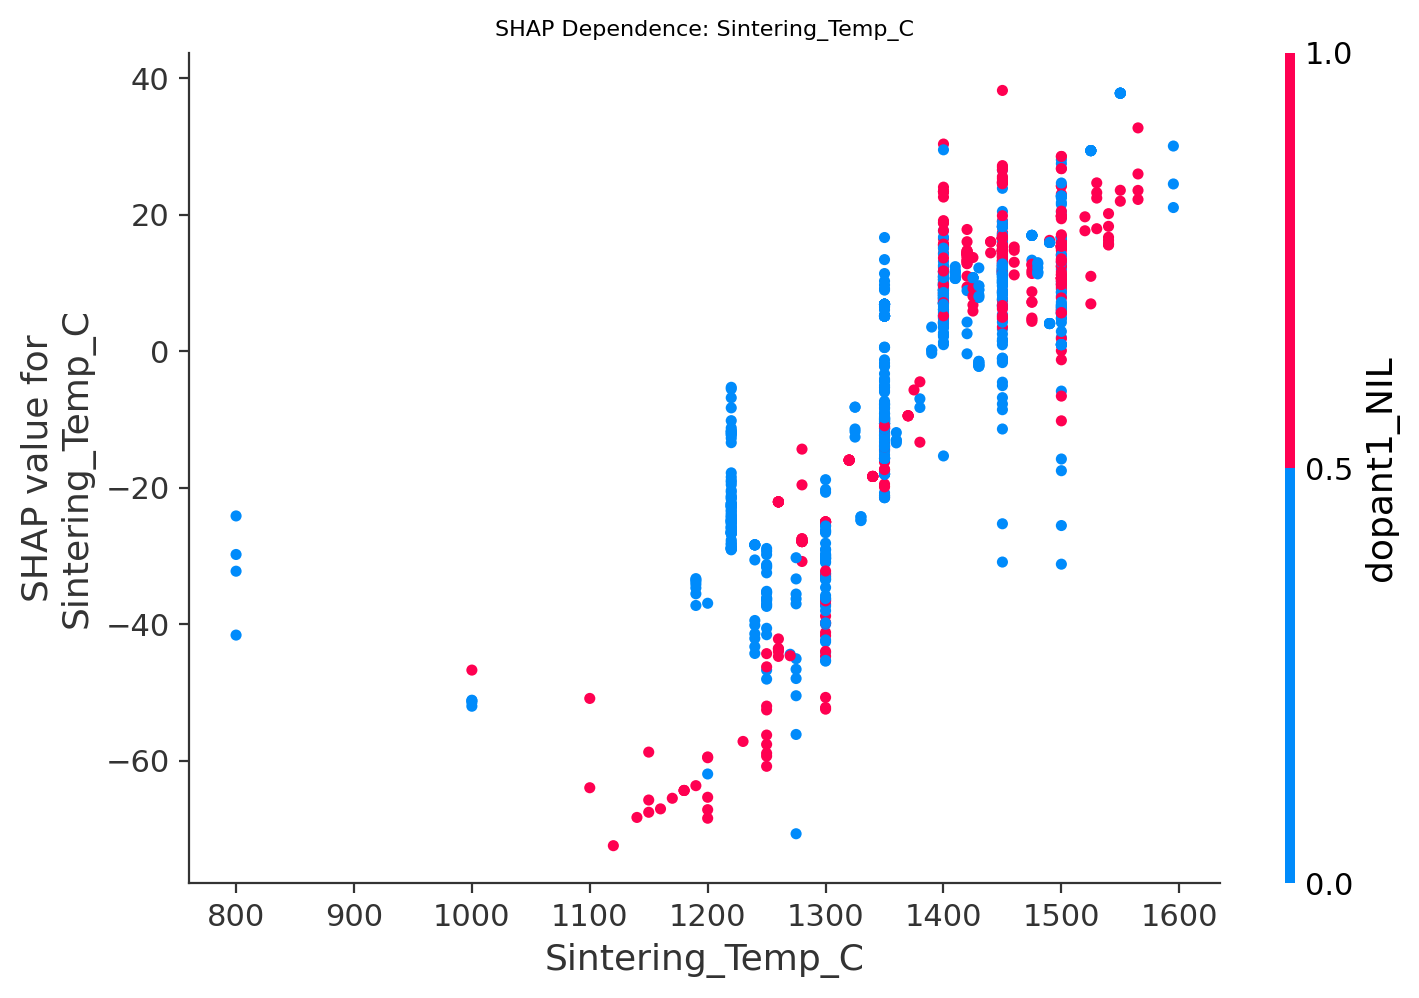

<Figure size 1000x800 with 0 Axes>

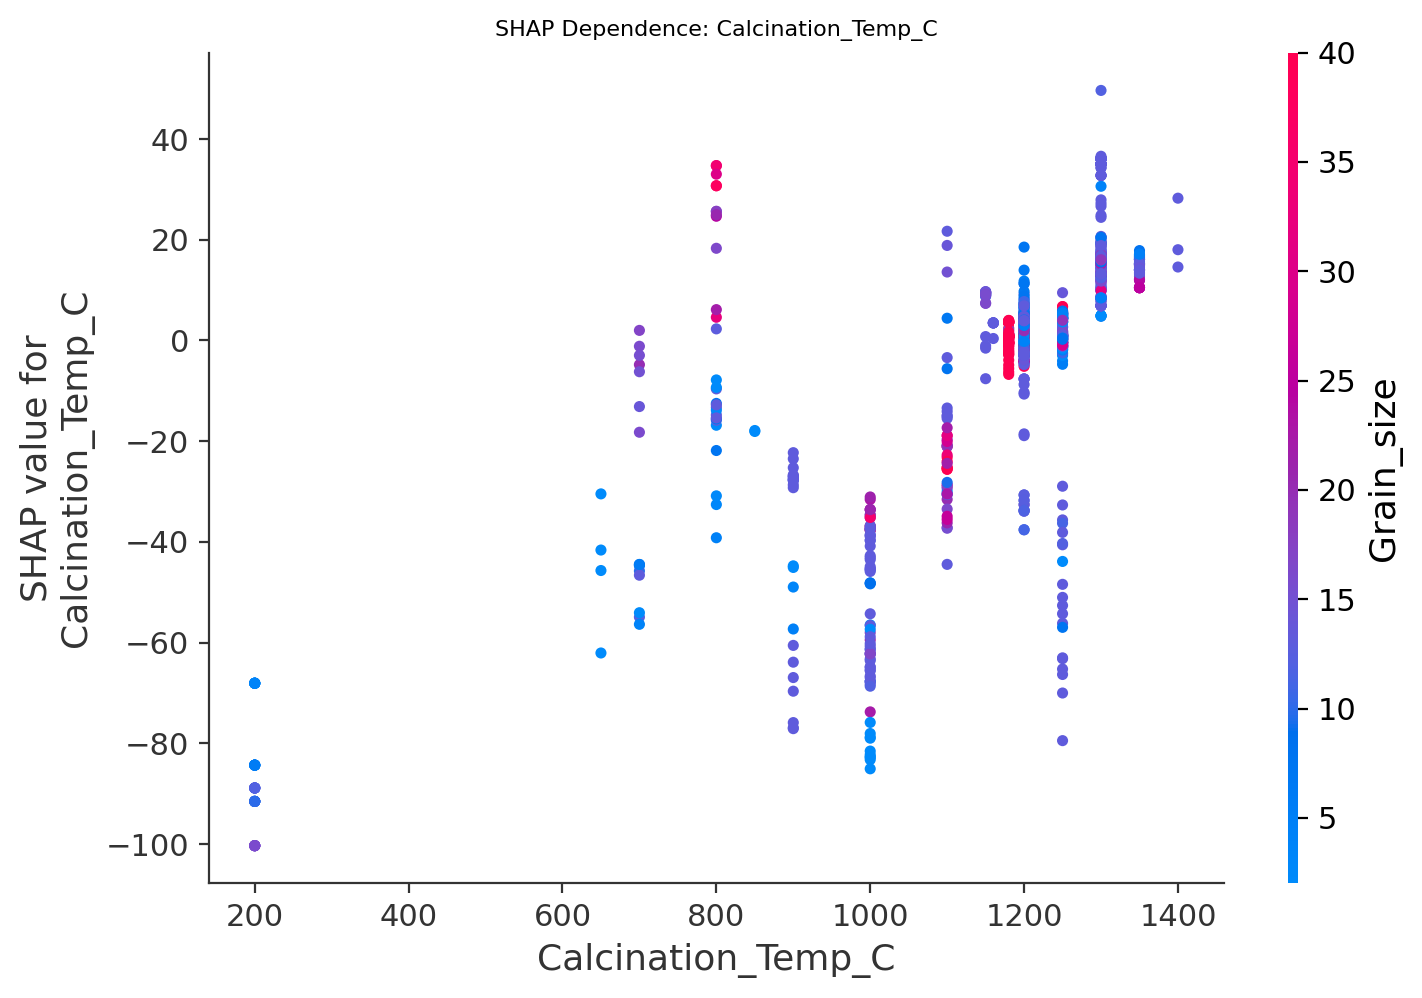

<Figure size 1000x800 with 0 Axes>

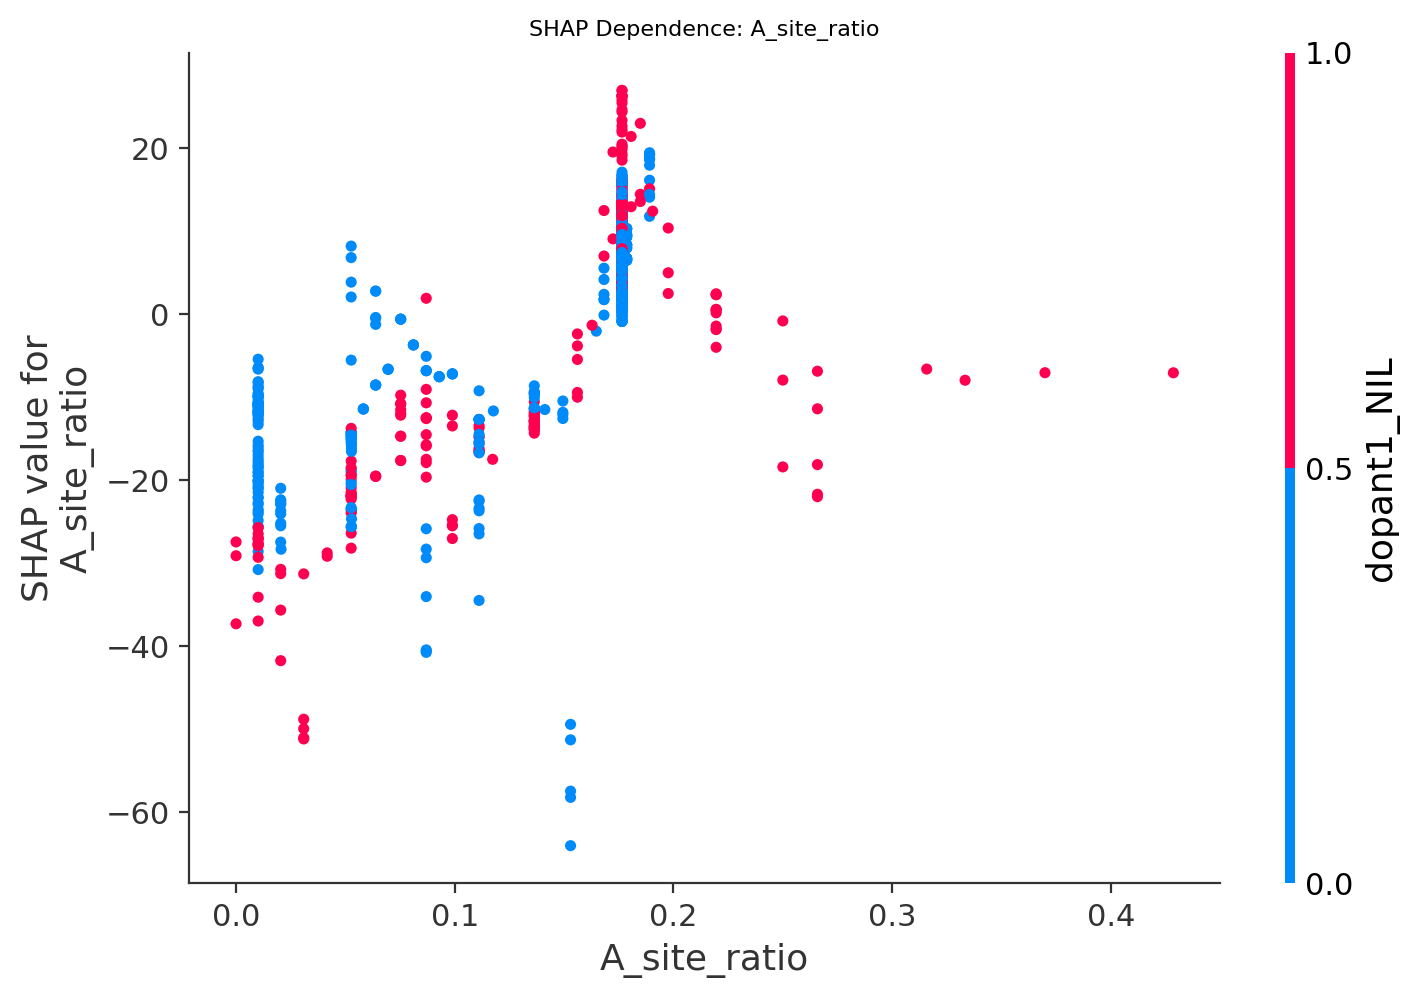

In [30]:
# ============================================================
# Chunk 28: Step 20 — Processing–structure relationship plots
# Partial dependence: how each key processing/microstructure feature
# relates to predicted d33, holding other features at their typical
# (marginal) values across the dataset.
# Generic — picks whichever of these features exist in this tab's final_features.
# ============================================================

from sklearn.inspection import PartialDependenceDisplay

pd_features = [f for f in ['Tc', 'Grain_size', 'Sintering_Temp_C', 'Calcination_Temp_C', 'A_site_ratio', 'Ca']
               if f in final_features]
print(f"Partial dependence plots for: {pd_features}")

n_cols = 3
n_rows = -(-len(pd_features) // n_cols)  # ceiling division

disp = PartialDependenceDisplay.from_estimator(
    final_model, X_final, pd_features,
    kind='average', n_cols=n_cols,
    line_kw={'color': '#4C72B0', 'linewidth': 2}
)
disp.figure_.suptitle(f'{CHAMPION_NAME} — Partial Dependence: Processing/Structure vs Predicted d33', fontweight='bold', y=1.02)
disp.figure_.set_size_inches(4*n_cols, 3.5*n_rows)
plt.tight_layout()
plt.show()

# --- SHAP dependence plots: same features, colored by strongest interacting feature ---
for feat in pd_features:
    plt.figure(figsize=(5,4))
    shap.dependence_plot(feat, shap_values_final, X_final, feature_names=final_features, show=False)
    plt.title(f'SHAP Dependence: {feat}')
    plt.tight_layout()
    plt.show()

In [31]:
# ============================================================
# Chunk 29: Step 21 — Final prediction framework wrapper
# A reusable function: feed in a new composition/processing/dopant
# combination, get a predicted d33. Generic — built off whatever
# final_features this tab ended up with.
# ============================================================

def predict_d33(feature_dict, model=final_model, required_features=final_features):
    """
    feature_dict: dict mapping each name in `required_features` to a numeric value.
    Returns predicted d33 (float).
    """
    missing = [f for f in required_features if f not in feature_dict]
    if missing:
        raise ValueError(f"Missing required features: {missing}. "
                          f"Full required list: {required_features}")
    row = pd.DataFrame([{f: feature_dict[f] for f in required_features}])[required_features]
    return model.predict(row)[0]

# --- Example: predict for a representative "typical" sample (dataset medians) ---
example_input = X_final[final_features].median().to_dict()
example_pred = predict_d33(example_input)
print(f"Required inputs for this pipeline's model: {final_features}")
print(f"\nExample prediction (dataset medians as input):")
for k, v in example_input.items():
    print(f"  {k}: {v:.4f}")
print(f"\n  --> Predicted d33 = {example_pred:.2f}")

import joblib
fname = f'final_prediction_framework_{CHAMPION_NAME.replace(" ","_")}.pkl'
joblib.dump({'model': final_model, 'features': final_features, 'champion_name': CHAMPION_NAME}, fname)
print(f"\nSaved: {fname}")

Required inputs for this pipeline's model: ['Grain_size', 'Tc', 'Sintering_Temp_C', 'Calcination_Temp_C', 'd33_measured_temperature', 'synth_OTHER', 'A_site_ratio', 'dopant1_NIL', 'Percentage_of_dopant1', 'synth_SOL-GEL', 'dopant1_CeO2', 'dopant1_CuO', 'dopant1_Ce']

Example prediction (dataset medians as input):
  Grain_size: 13.0000
  Tc: 92.0000
  Sintering_Temp_C: 1400.0000
  Calcination_Temp_C: 1200.0000
  d33_measured_temperature: 25.0000
  synth_OTHER: 0.0000
  A_site_ratio: 0.1765
  dopant1_NIL: 0.0000
  Percentage_of_dopant1: 0.0010
  synth_SOL-GEL: 0.0000
  dopant1_CeO2: 0.0000
  dopant1_CuO: 0.0000
  dopant1_Ce: 0.0000

  --> Predicted d33 = 380.20

Saved: final_prediction_framework_Extra_Trees.pkl


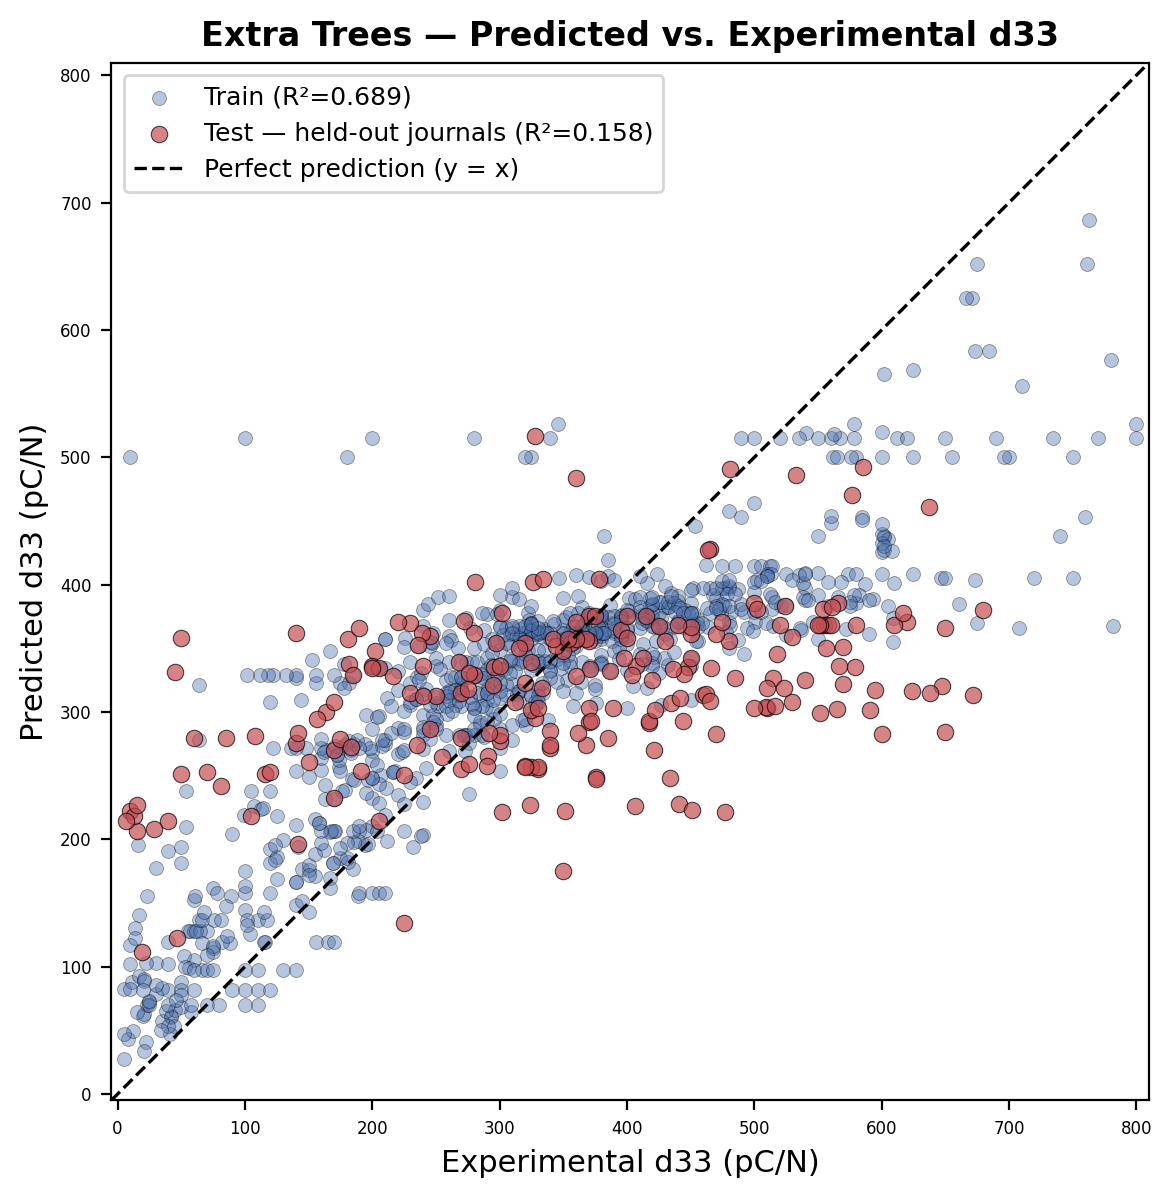

Saved: final_predicted_vs_experimental_Extra_Trees.png (300 dpi, publication-ready)


In [32]:
# ============================================================
# Chunk 30: Step 22 — Final polished predicted-vs-experimental plot
# Train (fit) + test (held-out journals) predictions vs actual d33.
# 300 dpi, publication-ready.
# ============================================================

y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_train, y_train_pred, alpha=0.4, s=25, color='#4C72B0', edgecolor='k', linewidth=0.3,
           label=f'Train (R²={train_r2:.3f})')
ax.scatter(y_test, y_test_pred, alpha=0.7, s=35, color='#C44E52', edgecolor='k', linewidth=0.4,
           label=f'Test — held-out journals (R²={test_r2:.3f})')

lims = [min(y_train.min(), y_test.min())-10, max(y_train.max(), y_test.max())+10]
ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect prediction (y = x)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Experimental d33 (pC/N)', fontsize=11)
ax.set_ylabel('Predicted d33 (pC/N)', fontsize=11)
ax.set_title(f'{CHAMPION_NAME} — Predicted vs. Experimental d33', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
fname = f'final_predicted_vs_experimental_{CHAMPION_NAME.replace(" ","_")}.png'
plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fname} (300 dpi, publication-ready)")

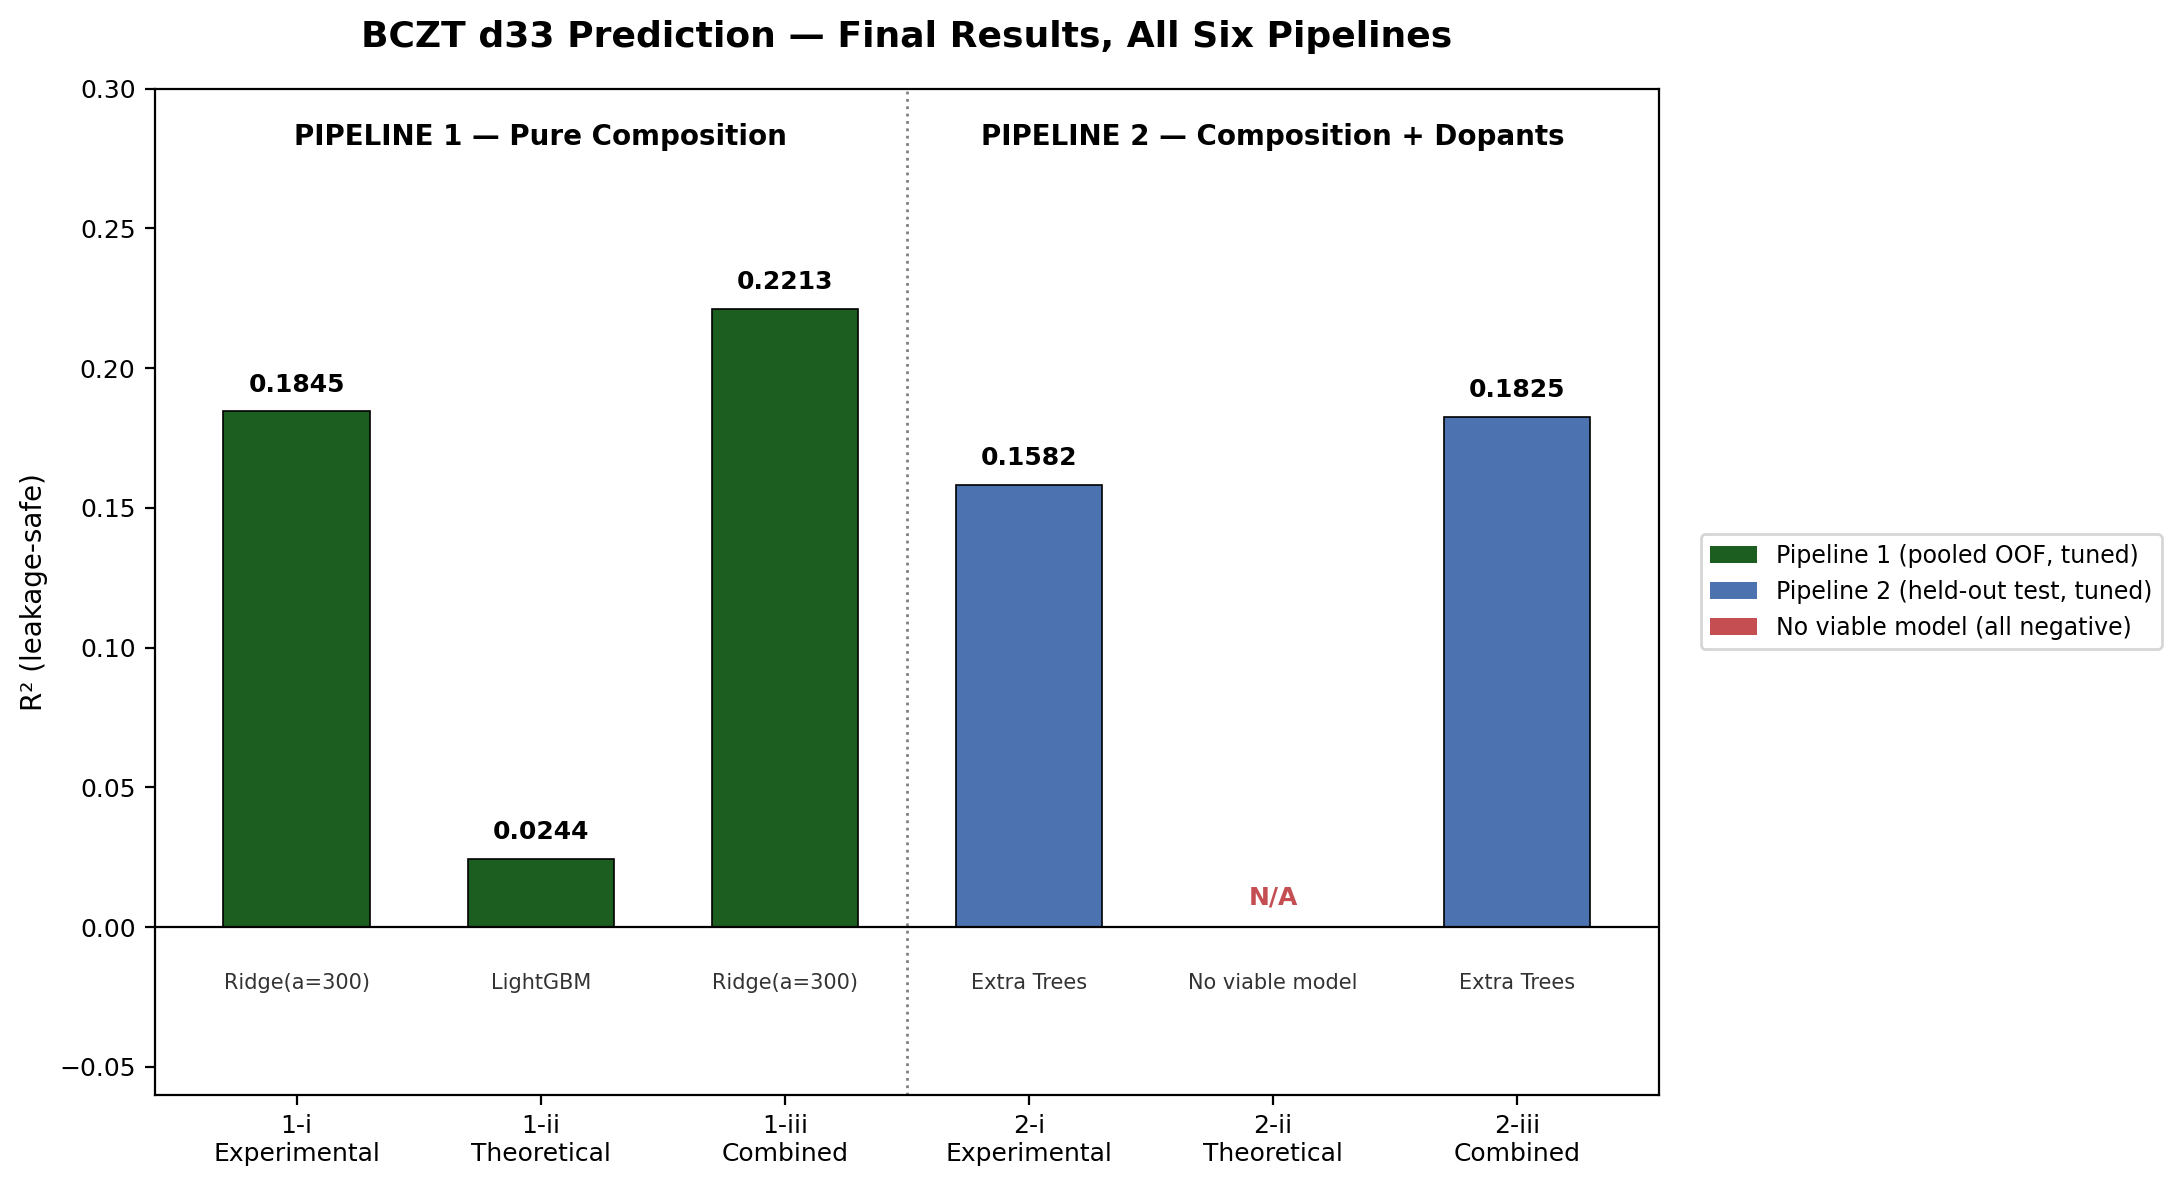